See conclusions about the requirements to prepare 5 notebooks with different SMOTE in `research_14_1_SMOTE_influence_on_metrics.ipynb`

# SMOTE influence on metrics

This notebook evaluates the influence of using SMOTE and SMOTENC, both with default parameters, on the resulting metrics. For SMOTENC, the features "wettability" and "inclination" were provided.

# Prerequisites

In [1]:
import os
from pathlib import Path
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import re
import ast

## Functions

In [2]:
def get_best_SMOTE_type(
    df:pd.DataFrame,
    metric_lists:list[list[str]]=None,
):
    """This function retrieves the best SMOTE type for each model class based on specified metrics.

    Args:
        df: DataFrame containing model performance metrics.
        metric_lists: List of metric names to evaluate. Defaults to None.
    """
    if metric_lists is None:
        metric_lists = [
            ['holdout_test_f1_macro', 'holdout_test_roc_auc', 'holdout_test_accuracy_balanced',],
            ['cv_test_f1_macro_median', 'cv_test_roc_auc_median', 'cv_test_accuracy_balanced_median',],
        ]

    metrics_by_target = {
        target: df[df['target'] == target]
        for target in df['target'].unique()
    }

    for target in metrics_by_target:
        # smote_by_target = {}
        for metric_list in metric_lists:
            print(target.upper())
            display(metric_list)
            metrics = metrics_by_target[target].groupby(
                ['model_class', 'SMOTE']
            )[metric_list].max()

            metrics = metrics.sort_values(by=metric_list, ascending=False)

            result = metrics.reset_index().groupby('model_class')['SMOTE'].first()

            display(result)
            print('Best SMOTE:', result.value_counts().idxmax())
            display(metrics)


## Load Data

In [3]:
df_metrics = pd.read_excel(
    Path(
        '../results/metrics_modelling4.xlsx'
    ),
)

display(df_metrics.head())
df_metrics.info()

,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_class_0_mean,cv_train_recall_class_0_median,cv_train_recall_class_0_std,cv_train_recall_mean,cv_train_recall_median,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std
0,df_dimless,splashing,Logit_splashing_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.800000,0.823529,0.875000,0.848485,0.874228,0.777184,...,0.784073,0.778761,0.017802,0.845821,0.844660,0.010156,"0.8959421541118067, 0.9114676936243047, 0.9020...",0.905980,0.907788,0.006070
1,df_dimless,no_fragmentation,Logit_no_fragmentation_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.906667,0.809524,0.850000,0.829268,0.951818,0.882524,...,0.916361,0.914530,0.012056,0.760984,0.752941,0.021087,"0.9395604395604396, 0.9486676721970839, 0.9361...",0.940673,0.941277,0.005873
2,df_dimless,splashing,LogisticRegression_splashing_default,"{'estimator': 'LogisticRegression', 'estimator...",0.800000,0.823529,0.875000,0.848485,0.879630,0.777184,...,0.803036,0.796460,0.021463,0.838192,0.834951,0.009285,"0.8971077055903303, 0.912665810868635, 0.90327...",0.907306,0.909206,0.006459
3,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_default,"{'estimator': 'LogisticRegression', 'estimator...",0.826667,0.629630,0.850000,0.723404,0.946364,0.798595,...,0.843712,0.846154,0.010179,0.878792,0.870588,0.014996,"0.9391534391534391, 0.949270990447461, 0.93559...",0.940457,0.941679,0.005749
4,df_dimless,splashing,KNeighborsClassifier_splashing_default,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.853333,0.862745,0.916667,0.888889,0.880787,0.836601,...,0.845942,0.849558,0.017741,0.916667,0.917476,0.010215,"0.9670192100151089, 0.9732563115104835, 0.9687...",0.968172,0.967738,0.002594


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Columns: 112 entries, dataset to cv_train_roc_auc_std
dtypes: float64(86), object(26)
memory usage: 147.1+ KB


## Apply SMOTE and pure model groups

In [4]:
df_metrics['model_class'] = df_metrics['model'].apply(
    lambda x: x.split('_')[0]
)

df_metrics['model_group'] = df_metrics['model'].apply(
    lambda x: x.split('_')[-1]
)
df_metrics['model_group'] = df_metrics['model_group'].apply(
    lambda x: 'default' if 'default' in x else 'opt'
)

def define_SMOTE(model):
    if 'smotenc' in model:
        return 'SMOTENC'
    elif 'smote' in model:
        return 'SMOTE'
    else:
        return 'no'
df_metrics['SMOTE'] = df_metrics['model'].apply(
    define_SMOTE
)

def define_SMOTE_opt(model):
    if 'smote' in model:
        if re.search(r'opt-[a-z-]*smote', model):
            if re.search(r'optuna-opt[a-z-]*smote', model):
                return 'optuna'
            else:
                return 'grid'
        else:
            return 'no'
    else:
        return None
df_metrics['SMOTE_opt'] = df_metrics['model'].apply(
    define_SMOTE_opt
)

def define_SMOTE_opt_type(model):
    if re.search(r'opt-[a-z-]*smote', model):
        if 'mean-smote' in model:
            return 'mean'
        else:
            return 'median'
    else:
        return None
df_metrics['SMOTE_opt_type'] = df_metrics['model'].apply(
    define_SMOTE_opt_type
)

df_metrics.head()

,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std,model_class,model_group,SMOTE,SMOTE_opt,SMOTE_opt_type
0,df_dimless,splashing,Logit_splashing_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.800000,0.823529,0.875000,0.848485,0.874228,0.777184,...,0.010156,"0.8959421541118067, 0.9114676936243047, 0.9020...",0.905980,0.907788,0.006070,Logit,default,no,None,None
1,df_dimless,no_fragmentation,Logit_no_fragmentation_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.906667,0.809524,0.850000,0.829268,0.951818,0.882524,...,0.021087,"0.9395604395604396, 0.9486676721970839, 0.9361...",0.940673,0.941277,0.005873,Logit,default,no,None,None
2,df_dimless,splashing,LogisticRegression_splashing_default,"{'estimator': 'LogisticRegression', 'estimator...",0.800000,0.823529,0.875000,0.848485,0.879630,0.777184,...,0.009285,"0.8971077055903303, 0.912665810868635, 0.90327...",0.907306,0.909206,0.006459,LogisticRegression,default,no,None,None
3,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_default,"{'estimator': 'LogisticRegression', 'estimator...",0.826667,0.629630,0.850000,0.723404,0.946364,0.798595,...,0.014996,"0.9391534391534391, 0.949270990447461, 0.93559...",0.940457,0.941679,0.005749,LogisticRegression,default,no,None,None
4,df_dimless,splashing,KNeighborsClassifier_splashing_default,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.853333,0.862745,0.916667,0.888889,0.880787,0.836601,...,0.010215,"0.9670192100151089, 0.9732563115104835, 0.9687...",0.968172,0.967738,0.002594,KNeighborsClassifier,default,no,None,None


## Analyse SMOTE

In [5]:
df_default = df_metrics[
    (df_metrics['model_group'] == 'default')
]
get_best_SMOTE_type(df=df_default)

SPLASHING


['holdout_test_f1_macro',
 'holdout_test_roc_auc',
 'holdout_test_accuracy_balanced']

model_class
AdaBoostClassifier             no
CatBoostClassifier          SMOTE
KNeighborsClassifier        SMOTE
LGBMClassifier            SMOTENC
LogisticRegression        SMOTENC
Logit                          no
RandomForestClassifier      SMOTE
SVC                         SMOTE
XGBClassifier             SMOTENC
Name: SMOTE, dtype: object

Best SMOTE: SMOTE


holdout_test_f1_macro  holdout_test_roc_auc  \
model_class            SMOTE                                                  
XGBClassifier          SMOTENC               0.896019              0.942901   
CatBoostClassifier     SMOTE                 0.882261              0.959877   
                       SMOTENC               0.882261              0.958333   
LGBMClassifier         SMOTENC               0.882261              0.957562   
                       no                    0.866310              0.951775   
CatBoostClassifier     no                    0.863609              0.956790   
LGBMClassifier         SMOTE                 0.863609              0.951775   
XGBClassifier          SMOTE                 0.863609              0.947145   
                       no                    0.863609              0.940972   
RandomForestClassifier SMOTE                 0.850000              0.956404   
                       no                    0.850000              0.943673   
KNeighborsClassifier   SMOTE                 0.842105              0.891204   
RandomForestClassifier SMOTENC               0.836601              0.951775   
KNeighborsClassifier   SMOTENC               0.836601              0.887346   
                       no                    0.836601              0.880787   
SVC                    SMOTE                 0.813397              0.904321   
                       SMOTENC               0.810348              0.906636   
                       no                    0.793956              0.911265   
LogisticRegression     SMOTENC               0.793956              0.885802   
                       SMOTE                 0.793956              0.885031   
AdaBoostClassifier     no                    0.793956              0.881559   
                       SMOTE                 0.784689              0.859182   
                       SMOTENC               0.781171              0.877701   
LogisticRegression     no                    0.777184              0.879630   
Logit                  no                    0.777184              0.874228   
                       SMOTENC               0.764521              0.871142   
                       SMOTE                 0.764521              0.868827   

                                holdout_test_accuracy_balanced  
model_class            SMOTE                                    
XGBClassifier          SMOTENC                        0.886574  
CatBoostClassifier     SMOTE                          0.876157  
                       SMOTENC                        0.876157  
LGBMClassifier         SMOTENC                        0.876157  
                       no                             0.857639  
CatBoostClassifier     no                             0.849537  
LGBMClassifier         SMOTE                          0.849537  
XGBClassifier          SMOTE                          0.849537  
                       no                             0.849537  
RandomForestClassifier SMOTE                          0.839120  
                       no                             0.839120  
KNeighborsClassifier   SMOTE                          0.844907  
RandomForestClassifier SMOTENC                        0.828704  
KNeighborsClassifier   SMOTENC                        0.834491  
                       no                             0.828704  
SVC                    SMOTE                          0.815972  
                       SMOTENC                        0.807870  
                       no                             0.789352  
LogisticRegression     SMOTENC                        0.789352  
                       SMOTE                          0.789352  
AdaBoostClassifier     no                             0.789352  
                       SMOTE                          0.787037  
                       SMOTENC                        0.778935  
LogisticRegression     no                             0.770833  
Logit                  no                         

...

NO_FRAGMENTATION


['cv_test_f1_macro_median',
 'cv_test_roc_auc_median',
 'cv_test_accuracy_balanced_median']

model_class
AdaBoostClassifier          SMOTE
CatBoostClassifier          SMOTE
KNeighborsClassifier      SMOTENC
LGBMClassifier            SMOTENC
LogisticRegression             no
Logit                       SMOTE
RandomForestClassifier      SMOTE
SVC                       SMOTENC
XGBClassifier                  no
Name: SMOTE, dtype: object

Best SMOTE: SMOTE


cv_test_f1_macro_median  \
model_class            SMOTE                              
CatBoostClassifier     SMOTE                   0.925457   
                       SMOTENC                 0.902930   
LGBMClassifier         SMOTENC                 0.898077   
                       SMOTE                   0.898077   
CatBoostClassifier     no                      0.898077   
LGBMClassifier         no                      0.898077   
RandomForestClassifier SMOTE                   0.898077   
                       SMOTENC                 0.898077   
SVC                    SMOTENC                 0.881326   
                       SMOTE                   0.881326   
KNeighborsClassifier   SMOTENC                 0.881326   
XGBClassifier          no                      0.875762   
                       SMOTENC                 0.875762   
                       SMOTE                   0.875762   
RandomForestClassifier no                      0.869136   
KNeighborsClassifier   SMOTE                   0.854396   
LogisticRegression     no                      0.854396   
AdaBoostClassifier     SMOTE                   0.854396   
KNeighborsClassifier   no                      0.835007   
Logit                  SMOTE                   0.828299   
LogisticRegression     SMOTENC                 0.826797   
                       SMOTE                   0.826797   
AdaBoostClassifier     SMOTENC                 0.826067   
                       no                      0.826067   
Logit                  no                      0.814035   
                       SMOTENC                 0.814035   
SVC                    no                      0.796154   

                                cv_test_roc_auc_median  \
model_class            SMOTE                             
CatBoostClassifier     SMOTE                  0.977778   
                       SMOTENC                0.974359   
LGBMClassifier         SMOTENC                0.979487   
                       SMOTE                  0.976068   
CatBoostClassifier     no                     0.974359   
LGBMClassifier         no                     0.958974   
RandomForestClassifier SMOTE                  0.954701   
                       SMOTENC                0.948718   
SVC                    SMOTENC                0.963370   
                       SMOTE                  0.957875   
KNeighborsClassifier   SMOTENC                0.931319   
XGBClassifier          no                     0.979487   
                       SMOTENC                0.978022   
                       SMOTE                  0.976068   
RandomForestClassifier no                     0.952991   
KNeighborsClassifier   SMOTE                  0.952381   
LogisticRegression     no                     0.945055   
AdaBoostClassifier     SMOTE                  0.934066   
KNeighborsClassifier   no                     0.932234   
Logit                  SMOTE                  0.935897   
LogisticRegression     SMOTENC                0.946886   
                       SMOTE                  0.946886   
AdaBoostClassifier     SMOTENC                0.941392   
                       no                     0.912088   
Logit                  no                     0.932234   
                       SMOTENC                0.930403   
SVC                    no                     0.943223   

                                cv_test_accuracy_balanced_median  
model_class            SMOTE                                      
CatBoostClassifier     SMOTE                            0.915751  
                       SMOTENC                          0.902930  
LGBMClassifier         SMOTENC                          0.902930  
                       SMOTE                            0.902930  
CatBoostClassifier     no                               0.880037  
LGBMClassifier         no                               0.890110  
RandomForestClassifier SMOTE                            0.880037  
                       SMOTENC    

## Get best SMOTE parameters

In [6]:
opt_methods = ['grid', 'optuna']
info_columns = [
    'model_class',
    'target',
    'SMOTE',
    'SMOTE_opt',
    'SMOTE_opt_type',
    'k_neighbors',
    'sampling_strategy',
]

split_types = ['test', 'train']
metrics = []
for split_type in split_types:
    metrics.extend(
        [
            f'holdout_{split_type}_f1_macro',
            f'holdout_{split_type}_roc_auc',
            f'holdout_{split_type}_accuracy_balanced',
            f'cv_{split_type}_f1_macro_median',
            f'cv_{split_type}_roc_auc_median',
            f'cv_{split_type}_accuracy_balanced_median',
        ]
    )


df = df_default[df_default['SMOTE_opt'].isin(opt_methods)]
def get_smote_params(row:pd.Series):
    smote_params_dict = ast.literal_eval(row['params'])['smote_params']
    
    for key, value in smote_params_dict.items():
        row[key] = value 
        
    return row

df = df.apply(get_smote_params, axis=1)

df = df[
    [
        *info_columns,
        *metrics,
    ]
]

df = df.sort_values(by=metrics[:6], ascending=False)
df

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.000000,0.995726
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,LogisticRegression,splashing,SMOTE,grid,mean,4,1.00,0.768519,0.879630,0.768519,0.802827,0.877709,0.818111,0.828475,0.919519,0.850818,0.814764,0.913416,0.837679
80,AdaBoostClassifier,splashing,SMOTENC,grid,median,3,0.60,0.764521,0.877701,0.760417,0.813161,0.905573,0.809598,0.944388,0.994593,0.941518,0.922108,0.986618,0.927485
130,AdaBoostClassifier,splashing,SMOTE,optuna,mean,8,0.91,0.755981,0.846065,0.758102,0.805718,0.885449,0.829721,0.944873,0.992237,0.945833,0.905517,0.983611,0.910291
64,AdaBoostClassifier,splashing,SMOTE,grid,median,3,0.70,0.751994,0.854552,0.750000,0.794892,0.891641,0.794892,0.974048,0.997098,0.970982,0.918719,0.985952,0.923769


### Full and half datasets (all models)

Size of the full_target_df for splashing: 48 rows
Size of the target_df for splashing: 48 rows
Models composition:


XGBClassifier             6
CatBoostClassifier        6
LGBMClassifier            6
KNeighborsClassifier      6
RandomForestClassifier    6
SVC                       6
LogisticRegression        6
AdaBoostClassifier        6
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    24
SMOTE      24
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.90,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 48 rows
Size of the target_df for no_fragmentation: 48 rows
Models composition:


LGBMClassifier            6
CatBoostClassifier        6
XGBClassifier             6
RandomForestClassifier    6
SVC                       6
AdaBoostClassifier        6
KNeighborsClassifier      6
LogisticRegression        6
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    24
SMOTE      24
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.000000,0.995726
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.999950,0.995726
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.999950,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


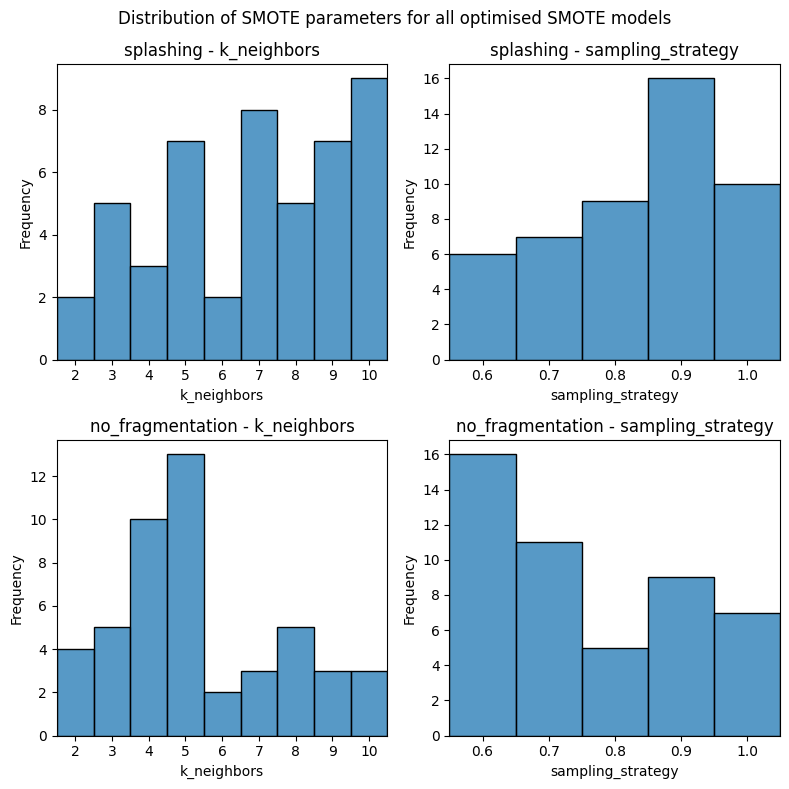

In [7]:
def plot_SMOTE_params_distribution(
    plot_df:pd.DataFrame,
    top_n:int=None,
    title:str=None,
    verbose:bool=False,
    save_path:str=Path('../results/SMOTE_params'),
    save_name:str=None,
):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

    for i, target in enumerate(['splashing', 'no_fragmentation']):
        full_target_df = plot_df[plot_df['target']==target]
        if top_n:
            target_df = full_target_df.head(top_n)
        else:
            target_df = full_target_df
        for j, param in enumerate(['k_neighbors', 'sampling_strategy']):
            if param == 'k_neighbors':
                binwidth = 1
                binrange = (1.5, 10.5)
                xticks = np.arange(2, 11)
                # bins = 4
            else:
                binwidth = 0.1
                binrange = (0.55, 1.05)
                xticks = np.arange(0.6, 1.01, 0.1)
            # target_df[param].plot.hist(ax=axes[i, j], bins=bins)
            sns.histplot(
                data=target_df,
                x=param,
                binwidth=binwidth,
                binrange=binrange,
                ax=axes[i, j],
            )
            axes[i, j].set_title(f'{target} - {param}')
            axes[i, j].set_xlabel(param)
            axes[i, j].set_ylabel('Frequency')
            axes[i, j].set_xlim(binrange)
            axes[i, j].set_xticks(xticks)
            
        if verbose:
            print(f'Size of the full_target_df for {target}: {full_target_df.shape[0]} rows')
            print(f'Size of the target_df for {target}: {target_df.shape[0]} rows')
            print(f'Models composition:')
            display(target_df['model_class'].value_counts())
            print(f'SMOTE types:')
            display(target_df['SMOTE'].value_counts())
            if top_n:
                display(target_df.head(top_n))
            else:
                display(target_df)
            

    if title:
        fig.suptitle(title)
        plt.tight_layout()
        plt.show()
        
    if save_name:
        fig.savefig(
            Path(
                save_path,
                f'{save_name}.pdf'
            ),
            dpi=600,
        )
        
plot_SMOTE_params_distribution(
    plot_df=df,
    title='Distribution of SMOTE parameters for all optimised SMOTE models',
    verbose=True,
    save_name='SMOTE_params_distribution_1_1_all_models',
)

Half dataset

Size of the full_target_df for splashing: 48 rows
Size of the target_df for splashing: 24 rows
Models composition:


XGBClassifier             6
CatBoostClassifier        6
LGBMClassifier            6
KNeighborsClassifier      3
RandomForestClassifier    3
Name: model_class, dtype: int64

SMOTE types:


SMOTE      14
SMOTENC    10
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.90,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 48 rows
Size of the target_df for no_fragmentation: 24 rows
Models composition:


LGBMClassifier            6
CatBoostClassifier        6
XGBClassifier             6
RandomForestClassifier    6
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    12
SMOTE      12
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.00000,0.995726
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.99995,0.995726
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.99995,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


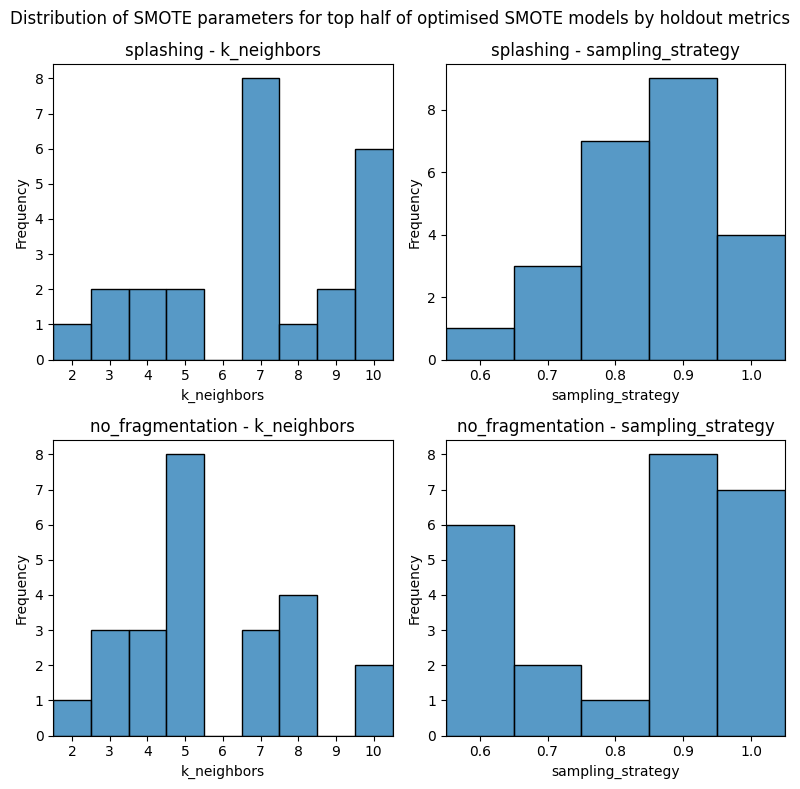

In [8]:
plot_SMOTE_params_distribution(
    plot_df=df,
    top_n=24,
    title='Distribution of SMOTE parameters for top half of optimised SMOTE models by holdout metrics',
    verbose=True,
    save_name='SMOTE_params_distribution_1_2_top_half_models',
)

### Division by models type

Size of the full_target_df for splashing: 18 rows
Size of the target_df for splashing: 18 rows
Models composition:


KNeighborsClassifier    6
SVC                     6
LogisticRegression      6
Name: model_class, dtype: int64

SMOTE types:


SMOTE      9
SMOTENC    9
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
106,KNeighborsClassifier,splashing,SMOTE,grid,mean,10,0.80,0.842105,0.874228,0.844907,0.842262,0.923375,0.859133,0.881535,0.976612,0.892485,0.885678,0.974031,0.893505
154,KNeighborsClassifier,splashing,SMOTENC,optuna,mean,9,0.73,0.836601,0.883488,0.828704,0.844575,0.930075,0.870743,0.891299,0.974082,0.898140,0.886453,0.972592,0.892255
122,KNeighborsClassifier,splashing,SMOTE,optuna,mean,9,0.95,0.829027,0.891204,0.834491,0.846377,0.929323,0.876935,0.896614,0.979167,0.911533,0.887862,0.976093,0.905413
108,SVC,splashing,SMOTE,grid,mean,10,1.00,0.813397,0.904321,0.815972,0.826230,0.922601,0.856037,0.875636,0.948884,0.891592,0.867271,0.946838,0.880939
138,KNeighborsClassifier,splashing,SMOTENC,grid,mean,9,1.00,0.813397,0.880015,0.815972,0.844575,0.916409,0.870743,0.896614,0.976265,0.911533,0.890327,0.973967,0.901925
74,SVC,splashing,SMOTENC,grid,median,5,0.60,0.810348,0.906636,0.807870,0.863049,0.928793,0.876935,0.877724,0.948884,0.887723,0.872228,0.949845,0.879801
140,SVC,splashing,SMOTENC,grid,mean,6,0.90,0.810348,0.900463,0.807870,0.860788,0.928793,0.873839,0.878991,0.948438,0.894196,0.863739,0.945592,0.876514
156,SVC,splashing,SMOTENC,optuna,mean,8,0.92,0.810348,0.893519,0.807870,0.844575,0.934985,0.870743,0.878583,0.951215,0.892039,0.866850,0.946366,0.877373
124,SVC,splashing,SMOTE,optuna,mean,5,0.86,0.810348,0.881944,0.807870,0.844575,0.925697,0.870743,0.881951,0.946801,0.894643,0.863739,0.946665,0.876514
56,KNeighborsClassifier,splashing,SMOTE,grid,median,5,0.70,0.810348,0.874228,0.807870,0.835913,0.918731,0.844427,0.887457,0.973884,0.893378,0.888444,0.972957,0.897070


Size of the full_target_df for no_fragmentation: 18 rows
Size of the target_df for no_fragmentation: 18 rows
Models composition:


SVC                     6
KNeighborsClassifier    6
LogisticRegression      6
Name: model_class, dtype: int64

SMOTE types:


SMOTE      9
SMOTENC    9
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
125,SVC,no_fragmentation,SMOTE,optuna,mean,3,0.67,0.857143,0.950909,0.886364,0.881326,0.948718,0.890110,0.878079,0.963012,0.902944,0.857399,0.954449,0.885093
59,SVC,no_fragmentation,SMOTE,grid,median,9,0.70,0.857143,0.950000,0.886364,0.850704,0.948718,0.877289,0.869951,0.961154,0.894321,0.865626,0.959226,0.902778
157,SVC,no_fragmentation,SMOTENC,optuna,mean,4,0.72,0.843227,0.952727,0.877273,0.850704,0.961538,0.890110,0.869951,0.962838,0.894321,0.865626,0.960282,0.899522
139,KNeighborsClassifier,no_fragmentation,SMOTENC,grid,mean,5,0.70,0.834656,0.947727,0.845455,0.854396,0.931319,0.854396,0.893613,0.976164,0.916154,0.875179,0.977275,0.899522
155,KNeighborsClassifier,no_fragmentation,SMOTENC,optuna,mean,4,0.63,0.834656,0.945455,0.845455,0.847115,0.931319,0.848718,0.906210,0.974103,0.931106,0.883122,0.974811,0.899420
109,SVC,no_fragmentation,SMOTE,grid,mean,4,0.70,0.833300,0.951818,0.884091,0.850704,0.956044,0.890110,0.853895,0.966380,0.890924,0.865891,0.958924,0.893640
75,SVC,no_fragmentation,SMOTENC,grid,median,4,0.60,0.825397,0.958182,0.852273,0.850704,0.950549,0.890110,0.882537,0.962083,0.909273,0.852710,0.957416,0.884565
141,SVC,no_fragmentation,SMOTENC,grid,mean,4,0.70,0.825397,0.951818,0.852273,0.850704,0.957875,0.890110,0.874436,0.963419,0.900650,0.859269,0.958622,0.888311
107,KNeighborsClassifier,no_fragmentation,SMOTE,grid,mean,5,0.70,0.825397,0.944545,0.852273,0.854396,0.939560,0.861722,0.898738,0.980780,0.926518,0.880075,0.976621,0.909150
123,KNeighborsClassifier,no_fragmentation,SMOTE,optuna,mean,8,0.84,0.825397,0.943636,0.852273,0.841642,0.951282,0.897436,0.887694,0.978574,0.919638,0.872580,0.980015,0.906486


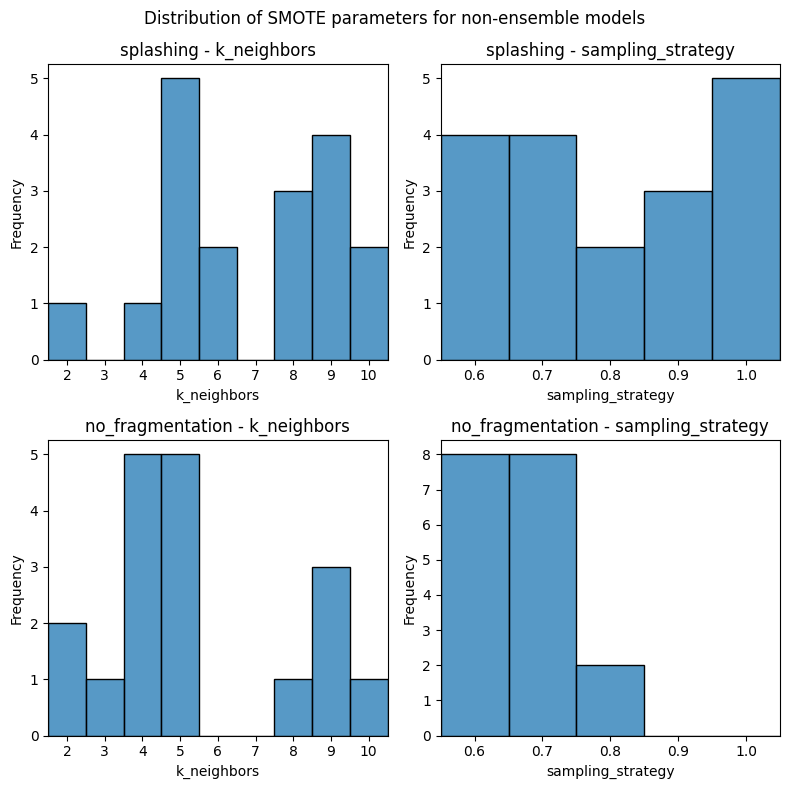

In [9]:
non_ensemble_models = [
    'LogisticRegression',
    'KNeighborsClassifier',
    'SVC',
]

plot_SMOTE_params_distribution(
    plot_df=df[df['model_class'].isin(non_ensemble_models)],
    # top_n=24,
    title='Distribution of SMOTE parameters for non-ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_2_1_non_ensemble_models',
)

Size of the full_target_df for splashing: 18 rows
Size of the target_df for splashing: 9 rows
Models composition:


SVC                     5
KNeighborsClassifier    4
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    5
SMOTE      4
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
106,KNeighborsClassifier,splashing,SMOTE,grid,mean,10,0.80,0.842105,0.874228,0.844907,0.842262,0.923375,0.859133,0.881535,0.976612,0.892485,0.885678,0.974031,0.893505
154,KNeighborsClassifier,splashing,SMOTENC,optuna,mean,9,0.73,0.836601,0.883488,0.828704,0.844575,0.930075,0.870743,0.891299,0.974082,0.898140,0.886453,0.972592,0.892255
122,KNeighborsClassifier,splashing,SMOTE,optuna,mean,9,0.95,0.829027,0.891204,0.834491,0.846377,0.929323,0.876935,0.896614,0.979167,0.911533,0.887862,0.976093,0.905413
108,SVC,splashing,SMOTE,grid,mean,10,1.00,0.813397,0.904321,0.815972,0.826230,0.922601,0.856037,0.875636,0.948884,0.891592,0.867271,0.946838,0.880939
138,KNeighborsClassifier,splashing,SMOTENC,grid,mean,9,1.00,0.813397,0.880015,0.815972,0.844575,0.916409,0.870743,0.896614,0.976265,0.911533,0.890327,0.973967,0.901925
74,SVC,splashing,SMOTENC,grid,median,5,0.60,0.810348,0.906636,0.807870,0.863049,0.928793,0.876935,0.877724,0.948884,0.887723,0.872228,0.949845,0.879801
140,SVC,splashing,SMOTENC,grid,mean,6,0.90,0.810348,0.900463,0.807870,0.860788,0.928793,0.873839,0.878991,0.948438,0.894196,0.863739,0.945592,0.876514
156,SVC,splashing,SMOTENC,optuna,mean,8,0.92,0.810348,0.893519,0.807870,0.844575,0.934985,0.870743,0.878583,0.951215,0.892039,0.866850,0.946366,0.877373
124,SVC,splashing,SMOTE,optuna,mean,5,0.86,0.810348,0.881944,0.807870,0.844575,0.925697,0.870743,0.881951,0.946801,0.894643,0.863739,0.946665,0.876514


Size of the full_target_df for no_fragmentation: 18 rows
Size of the target_df for no_fragmentation: 9 rows
Models composition:


SVC                     6
KNeighborsClassifier    3
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    5
SMOTE      4
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
125,SVC,no_fragmentation,SMOTE,optuna,mean,3,0.67,0.857143,0.950909,0.886364,0.881326,0.948718,0.890110,0.878079,0.963012,0.902944,0.857399,0.954449,0.885093
59,SVC,no_fragmentation,SMOTE,grid,median,9,0.70,0.857143,0.950000,0.886364,0.850704,0.948718,0.877289,0.869951,0.961154,0.894321,0.865626,0.959226,0.902778
157,SVC,no_fragmentation,SMOTENC,optuna,mean,4,0.72,0.843227,0.952727,0.877273,0.850704,0.961538,0.890110,0.869951,0.962838,0.894321,0.865626,0.960282,0.899522
139,KNeighborsClassifier,no_fragmentation,SMOTENC,grid,mean,5,0.70,0.834656,0.947727,0.845455,0.854396,0.931319,0.854396,0.893613,0.976164,0.916154,0.875179,0.977275,0.899522
155,KNeighborsClassifier,no_fragmentation,SMOTENC,optuna,mean,4,0.63,0.834656,0.945455,0.845455,0.847115,0.931319,0.848718,0.906210,0.974103,0.931106,0.883122,0.974811,0.899420
109,SVC,no_fragmentation,SMOTE,grid,mean,4,0.70,0.833300,0.951818,0.884091,0.850704,0.956044,0.890110,0.853895,0.966380,0.890924,0.865891,0.958924,0.893640
75,SVC,no_fragmentation,SMOTENC,grid,median,4,0.60,0.825397,0.958182,0.852273,0.850704,0.950549,0.890110,0.882537,0.962083,0.909273,0.852710,0.957416,0.884565
141,SVC,no_fragmentation,SMOTENC,grid,mean,4,0.70,0.825397,0.951818,0.852273,0.850704,0.957875,0.890110,0.874436,0.963419,0.900650,0.859269,0.958622,0.888311
107,KNeighborsClassifier,no_fragmentation,SMOTE,grid,mean,5,0.70,0.825397,0.944545,0.852273,0.854396,0.939560,0.861722,0.898738,0.980780,0.926518,0.880075,0.976621,0.909150


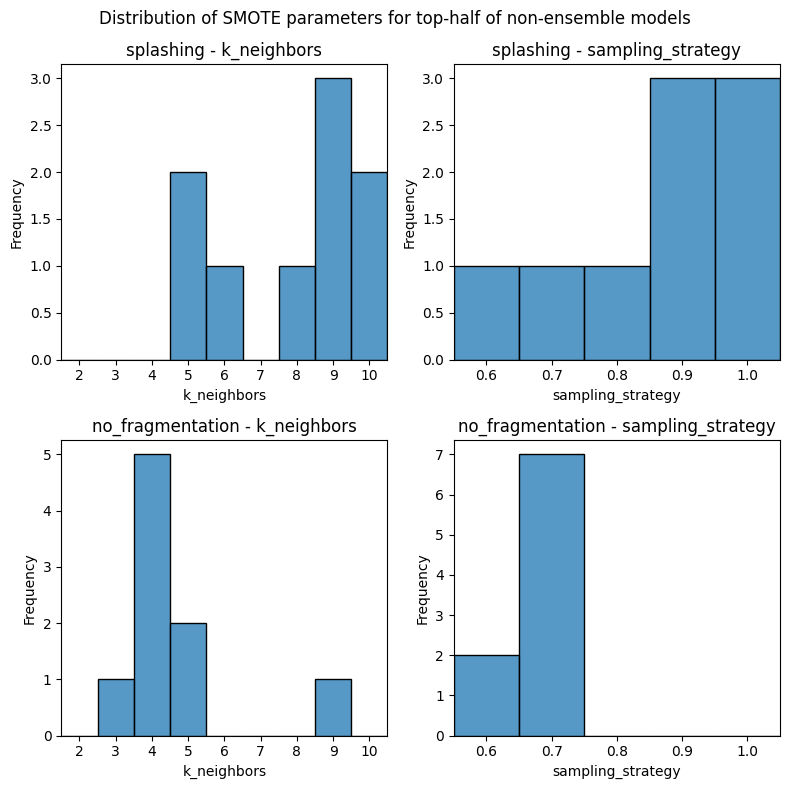

In [10]:
non_ensemble_models = [
    'LogisticRegression',
    'KNeighborsClassifier',
    'SVC',
]

plot_SMOTE_params_distribution(
    plot_df=df[df['model_class'].isin(non_ensemble_models)],
    top_n=9,
    title='Distribution of SMOTE parameters for top-half of non-ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_2_2_top_half_non_ensemble_models',
)

Size of the full_target_df for splashing: 30 rows
Size of the target_df for splashing: 30 rows
Models composition:


XGBClassifier             6
CatBoostClassifier        6
LGBMClassifier            6
RandomForestClassifier    6
AdaBoostClassifier        6
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    15
SMOTE      15
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.90,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 30 rows
Size of the target_df for no_fragmentation: 30 rows
Models composition:


LGBMClassifier            6
CatBoostClassifier        6
XGBClassifier             6
RandomForestClassifier    6
AdaBoostClassifier        6
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    15
SMOTE      15
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.000000,0.995726
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.999950,0.995726
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.999950,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


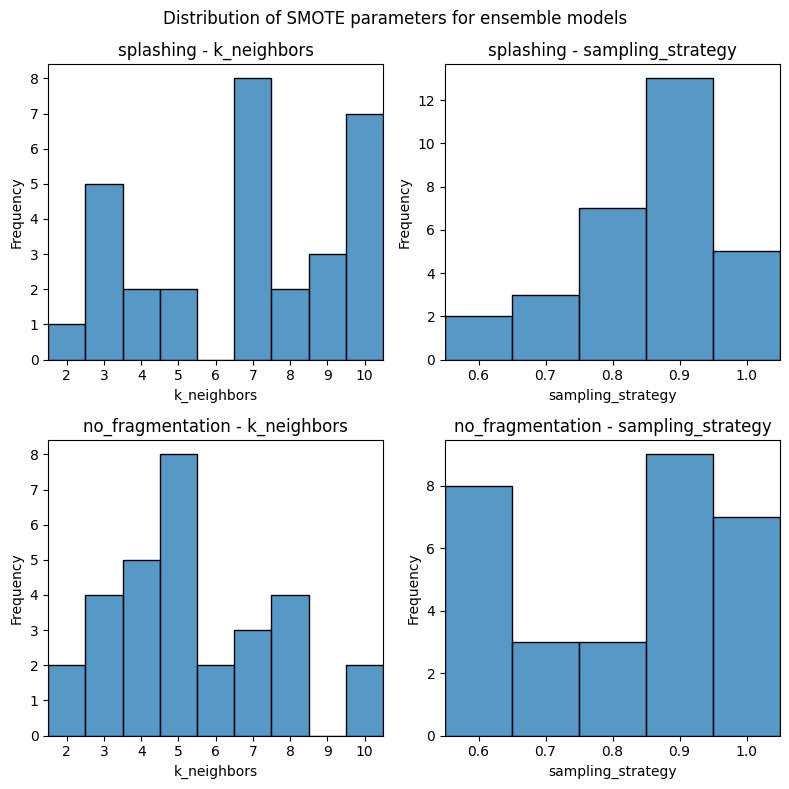

In [11]:
ensemble_models = [
    'RandomForestClassifier',
    'XGBClassifier',
    'AdaBoostClassifier',
    'LGBMClassifier',
    'CatBoostClassifier',
]

plot_SMOTE_params_distribution(
    plot_df=df[df['model_class'].isin(ensemble_models)],
    # top_n=24,
    title='Distribution of SMOTE parameters for ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_3_1_ensemble_models',
)

Size of the full_target_df for splashing: 30 rows
Size of the target_df for splashing: 15 rows
Models composition:


XGBClassifier         5
CatBoostClassifier    5
LGBMClassifier        5
Name: model_class, dtype: int64

SMOTE types:


SMOTE      8
SMOTENC    7
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.90,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 30 rows
Size of the target_df for no_fragmentation: 15 rows
Models composition:


CatBoostClassifier        5
LGBMClassifier            4
RandomForestClassifier    4
XGBClassifier             2
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    8
SMOTE      7
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.00000,0.995726
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.99995,0.995726
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.99995,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


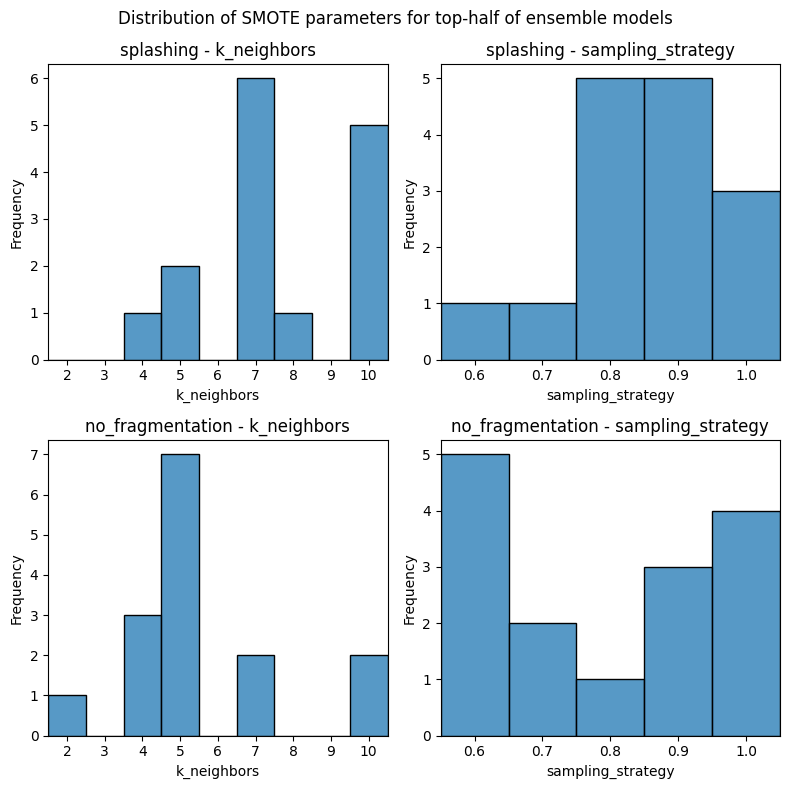

In [12]:
ensemble_models = [
    'RandomForestClassifier',
    'XGBClassifier',
    'AdaBoostClassifier',
    'LGBMClassifier',
    'CatBoostClassifier',
]

plot_SMOTE_params_distribution(
    plot_df=df[df['model_class'].isin(ensemble_models)],
    top_n=15,
    title='Distribution of SMOTE parameters for top-half of ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_3_2_top_half_ensemble_models',
)

### Division by SMOTE method

Size of the full_target_df for splashing: 24 rows
Size of the target_df for splashing: 24 rows
Models composition:


CatBoostClassifier        3
LGBMClassifier            3
XGBClassifier             3
KNeighborsClassifier      3
RandomForestClassifier    3
SVC                       3
LogisticRegression        3
AdaBoostClassifier        3
Name: model_class, dtype: int64

SMOTE types:


SMOTE    24
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
60,CatBoostClassifier,splashing,SMOTE,grid,median,10,0.60,0.846814,0.959877,0.831019,0.896201,0.950464,0.891641,0.996309,0.999975,0.995238,0.996567,0.999463,0.995575
106,KNeighborsClassifier,splashing,SMOTE,grid,mean,10,0.80,0.842105,0.874228,0.844907,0.842262,0.923375,0.859133,0.881535,0.976612,0.892485,0.885678,0.974031,0.893505
68,LGBMClassifier,splashing,SMOTE,grid,median,7,0.90,0.836601,0.951775,0.828704,0.898584,0.958730,0.903251,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
128,XGBClassifier,splashing,SMOTE,optuna,mean,7,0.94,0.836601,0.944830,0.828704,0.876935,0.953560,0.876935,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 24 rows
Size of the target_df for no_fragmentation: 24 rows
Models composition:


CatBoostClassifier        3
XGBClassifier             3
LGBMClassifier            3
RandomForestClassifier    3
SVC                       3
AdaBoostClassifier        3
KNeighborsClassifier      3
LogisticRegression        3
Name: model_class, dtype: int64

SMOTE types:


SMOTE    24
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.000000,0.995726
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.999950,0.995726
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
133,RandomForestClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.75,0.903516,0.980455,0.929545,0.875762,0.954701,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
111,CatBoostClassifier,no_fragmentation,SMOTE,grid,mean,7,0.60,0.897727,0.985455,0.897727,0.898077,0.969231,0.880037,0.991446,0.999826,0.995413,0.995975,1.000000,0.994118
67,RandomForestClassifier,no_fragmentation,SMOTE,grid,median,5,0.60,0.897727,0.980455,0.897727,0.898077,0.946154,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
69,LGBMClassifier,no_fragmentation,SMOTE,grid,median,3,0.90,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
119,LGBMClassifier,no_fragmentation,SMOTE,grid,mean,3,0.90,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
117,RandomForestClassifier,no_fragmentation,SMOTE,grid,mean,8,0.90,0.885894,0.977727,0.904545,0.875762,0.932479,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


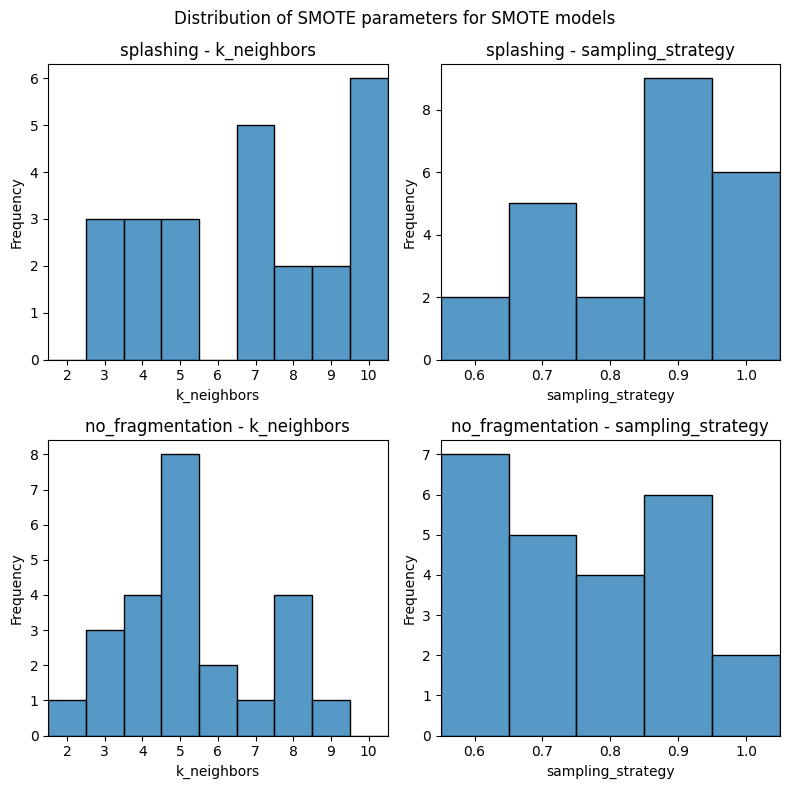

In [13]:
plot_SMOTE_params_distribution(
    plot_df=df[df['SMOTE'] == 'SMOTE'],
    # top_n=24,
    title='Distribution of SMOTE parameters for SMOTE models',
    verbose=True,
    save_name='SMOTE_params_distribution_4_1_SMOTE_models',
)

Size of the full_target_df for splashing: 24 rows
Size of the target_df for splashing: 12 rows
Models composition:


CatBoostClassifier        3
LGBMClassifier            3
XGBClassifier             3
KNeighborsClassifier      2
RandomForestClassifier    1
Name: model_class, dtype: int64

SMOTE types:


SMOTE    12
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
60,CatBoostClassifier,splashing,SMOTE,grid,median,10,0.60,0.846814,0.959877,0.831019,0.896201,0.950464,0.891641,0.996309,0.999975,0.995238,0.996567,0.999463,0.995575
106,KNeighborsClassifier,splashing,SMOTE,grid,mean,10,0.80,0.842105,0.874228,0.844907,0.842262,0.923375,0.859133,0.881535,0.976612,0.892485,0.885678,0.974031,0.893505
68,LGBMClassifier,splashing,SMOTE,grid,median,7,0.90,0.836601,0.951775,0.828704,0.898584,0.958730,0.903251,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
128,XGBClassifier,splashing,SMOTE,optuna,mean,7,0.94,0.836601,0.944830,0.828704,0.876935,0.953560,0.876935,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 24 rows
Size of the target_df for no_fragmentation: 12 rows
Models composition:


CatBoostClassifier        3
XGBClassifier             3
LGBMClassifier            3
RandomForestClassifier    3
Name: model_class, dtype: int64

SMOTE types:


SMOTE    12
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.00000,0.995726
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.99995,0.995726
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
133,RandomForestClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.75,0.903516,0.980455,0.929545,0.875762,0.954701,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
111,CatBoostClassifier,no_fragmentation,SMOTE,grid,mean,7,0.60,0.897727,0.985455,0.897727,0.898077,0.969231,0.880037,0.991446,0.999826,0.995413,0.995975,1.00000,0.994118
67,RandomForestClassifier,no_fragmentation,SMOTE,grid,median,5,0.60,0.897727,0.980455,0.897727,0.898077,0.946154,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
69,LGBMClassifier,no_fragmentation,SMOTE,grid,median,3,0.90,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
119,LGBMClassifier,no_fragmentation,SMOTE,grid,mean,3,0.90,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
117,RandomForestClassifier,no_fragmentation,SMOTE,grid,mean,8,0.90,0.885894,0.977727,0.904545,0.875762,0.932479,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


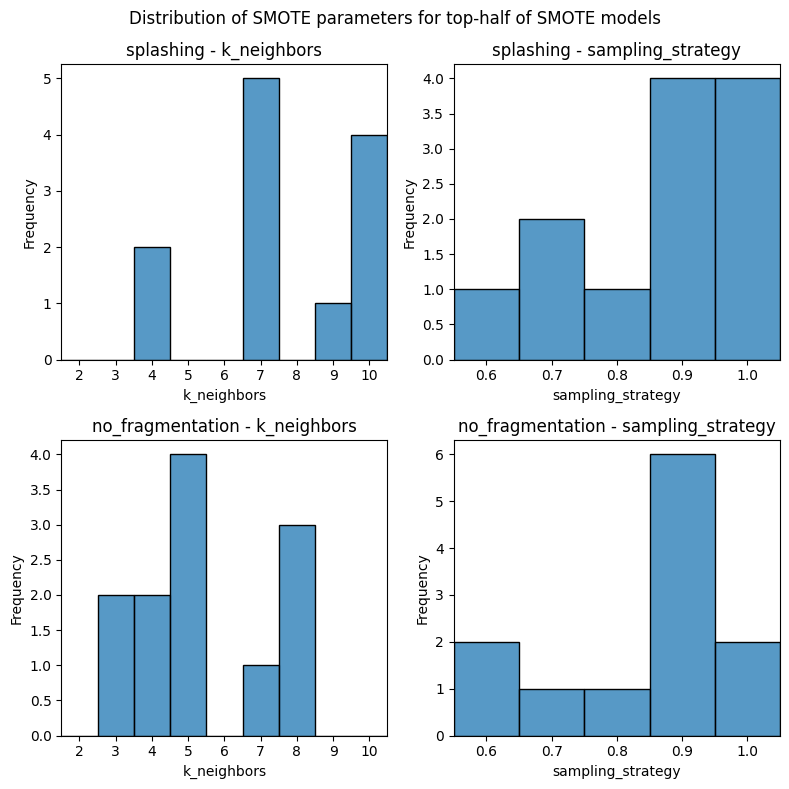

In [14]:
plot_SMOTE_params_distribution(
    plot_df=df[df['SMOTE'] == 'SMOTE'],
    top_n=12,
    title='Distribution of SMOTE parameters for top-half of SMOTE models',
    verbose=True,
    save_name='SMOTE_params_distribution_4_2_top_half_SMOTE_models',
)

Size of the full_target_df for splashing: 15 rows
Size of the target_df for splashing: 15 rows
Models composition:


CatBoostClassifier        3
LGBMClassifier            3
XGBClassifier             3
RandomForestClassifier    3
AdaBoostClassifier        3
Name: model_class, dtype: int64

SMOTE types:


SMOTE    15
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
60,CatBoostClassifier,splashing,SMOTE,grid,median,10,0.60,0.846814,0.959877,0.831019,0.896201,0.950464,0.891641,0.996309,0.999975,0.995238,0.996567,0.999463,0.995575
68,LGBMClassifier,splashing,SMOTE,grid,median,7,0.90,0.836601,0.951775,0.828704,0.898584,0.958730,0.903251,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
128,XGBClassifier,splashing,SMOTE,optuna,mean,7,0.94,0.836601,0.944830,0.828704,0.876935,0.953560,0.876935,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
66,RandomForestClassifier,splashing,SMOTE,grid,median,4,0.70,0.833300,0.956404,0.820602,0.896201,0.948413,0.891641,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 15 rows
Size of the target_df for no_fragmentation: 15 rows
Models composition:


CatBoostClassifier        3
XGBClassifier             3
LGBMClassifier            3
RandomForestClassifier    3
AdaBoostClassifier        3
Name: model_class, dtype: int64

SMOTE types:


SMOTE    15
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.000000,0.995726
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.999950,0.995726
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
133,RandomForestClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.75,0.903516,0.980455,0.929545,0.875762,0.954701,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
111,CatBoostClassifier,no_fragmentation,SMOTE,grid,mean,7,0.60,0.897727,0.985455,0.897727,0.898077,0.969231,0.880037,0.991446,0.999826,0.995413,0.995975,1.000000,0.994118
67,RandomForestClassifier,no_fragmentation,SMOTE,grid,median,5,0.60,0.897727,0.980455,0.897727,0.898077,0.946154,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
69,LGBMClassifier,no_fragmentation,SMOTE,grid,median,3,0.90,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
119,LGBMClassifier,no_fragmentation,SMOTE,grid,mean,3,0.90,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
117,RandomForestClassifier,no_fragmentation,SMOTE,grid,mean,8,0.90,0.885894,0.977727,0.904545,0.875762,0.932479,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


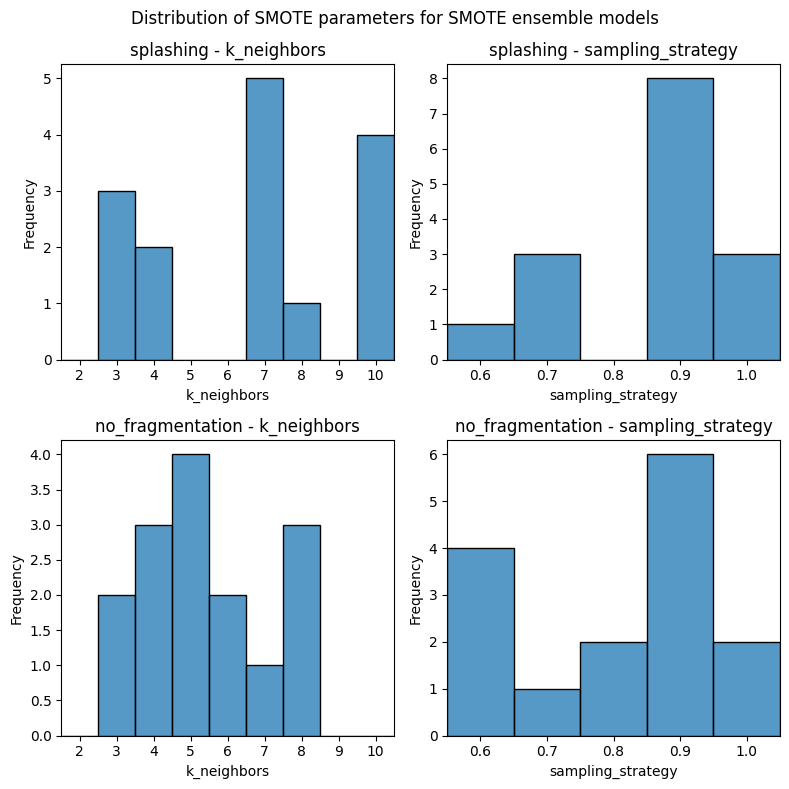

In [15]:
plot_SMOTE_params_distribution(
    plot_df=df[(df['SMOTE'] == 'SMOTE') & (df['model_class'].isin(ensemble_models))],
    # top_n=12,
    title='Distribution of SMOTE parameters for SMOTE ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_4_3_SMOTE_ensemble_models',
)

Size of the full_target_df for splashing: 15 rows
Size of the target_df for splashing: 8 rows
Models composition:


CatBoostClassifier    3
LGBMClassifier        3
XGBClassifier         2
Name: model_class, dtype: int64

SMOTE types:


SMOTE    8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
60,CatBoostClassifier,splashing,SMOTE,grid,median,10,0.60,0.846814,0.959877,0.831019,0.896201,0.950464,0.891641,0.996309,0.999975,0.995238,0.996567,0.999463,0.995575
68,LGBMClassifier,splashing,SMOTE,grid,median,7,0.90,0.836601,0.951775,0.828704,0.898584,0.958730,0.903251,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 15 rows
Size of the target_df for no_fragmentation: 8 rows
Models composition:


CatBoostClassifier        3
LGBMClassifier            2
RandomForestClassifier    2
XGBClassifier             1
Name: model_class, dtype: int64

SMOTE types:


SMOTE    8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.00,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.00000,0.995726
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.99995,0.995726
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
133,RandomForestClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.75,0.903516,0.980455,0.929545,0.875762,0.954701,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
111,CatBoostClassifier,no_fragmentation,SMOTE,grid,mean,7,0.60,0.897727,0.985455,0.897727,0.898077,0.969231,0.880037,0.991446,0.999826,0.995413,0.995975,1.00000,0.994118
67,RandomForestClassifier,no_fragmentation,SMOTE,grid,median,5,0.60,0.897727,0.980455,0.897727,0.898077,0.946154,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
69,LGBMClassifier,no_fragmentation,SMOTE,grid,median,3,0.90,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


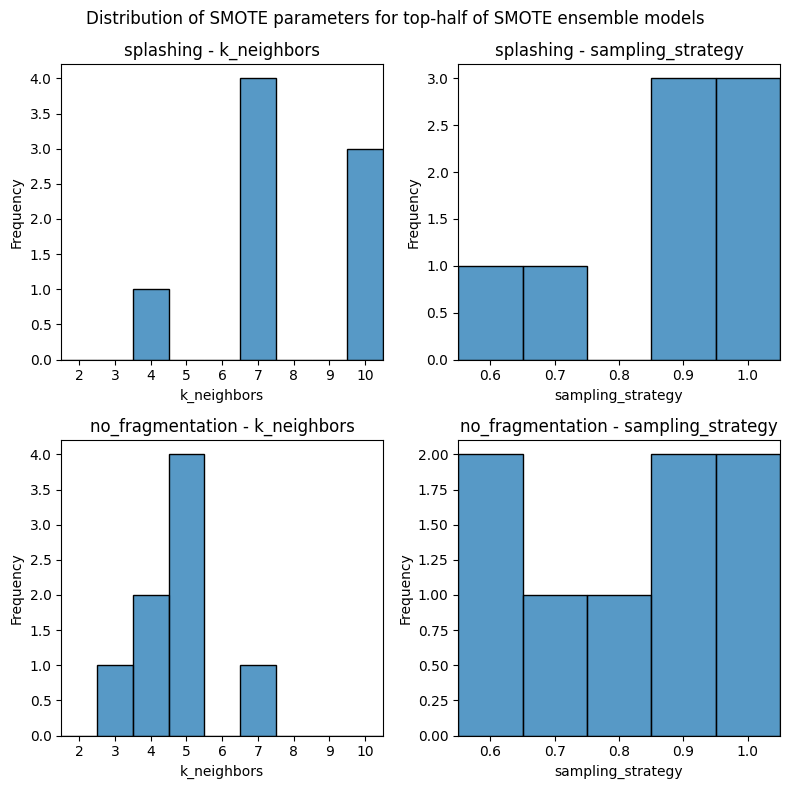

In [16]:
plot_SMOTE_params_distribution(
    plot_df=df[(df['SMOTE'] == 'SMOTE') & (df['model_class'].isin(ensemble_models))],
    top_n=8,
    title='Distribution of SMOTE parameters for top-half of SMOTE ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_4_4_top_half_SMOTE_ensemble_models',
)

Size of the full_target_df for splashing: 24 rows
Size of the target_df for splashing: 24 rows
Models composition:


XGBClassifier             3
CatBoostClassifier        3
LGBMClassifier            3
KNeighborsClassifier      3
RandomForestClassifier    3
SVC                       3
LogisticRegression        3
AdaBoostClassifier        3
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    24
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.90,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
158,CatBoostClassifier,splashing,SMOTENC,optuna,mean,7,0.75,0.850000,0.958333,0.839120,0.898584,0.945820,0.903251,0.996309,0.999678,0.995238,0.996567,0.999592,0.995575
144,XGBClassifier,splashing,SMOTENC,grid,mean,10,0.80,0.846814,0.942901,0.831019,0.879545,0.947619,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
166,LGBMClassifier,splashing,SMOTENC,optuna,mean,5,0.83,0.836601,0.948688,0.828704,0.879545,0.952012,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
84,LGBMClassifier,splashing,SMOTENC,grid,median,2,0.80,0.836601,0.939815,0.828704,0.896201,0.941270,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
154,KNeighborsClassifier,splashing,SMOTENC,optuna,mean,9,0.73,0.836601,0.883488,0.828704,0.844575,0.930075,0.870743,0.891299,0.974082,0.898140,0.886453,0.972592,0.892255
76,CatBoostClassifier,splashing,SMOTENC,grid,median,7,0.90,0.823391,0.952932,0.818287,0.860788,0.955108,0.873839,0.996309,0.999777,0.995238,0.996567,0.999592,0.995575


Size of the full_target_df for no_fragmentation: 24 rows
Size of the target_df for no_fragmentation: 24 rows
Models composition:


LGBMClassifier            3
XGBClassifier             3
CatBoostClassifier        3
RandomForestClassifier    3
SVC                       3
KNeighborsClassifier      3
AdaBoostClassifier        3
LogisticRegression        3
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    24
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.999950,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
83,RandomForestClassifier,no_fragmentation,SMOTENC,grid,median,5,0.70,0.900794,0.980000,0.913636,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
77,CatBoostClassifier,no_fragmentation,SMOTENC,grid,median,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.000000,1.000000
143,CatBoostClassifier,no_fragmentation,SMOTENC,grid,mean,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.000000,1.000000
145,XGBClassifier,no_fragmentation,SMOTENC,grid,mean,5,1.00,0.885894,0.988182,0.904545,0.875762,0.967033,0.877289,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


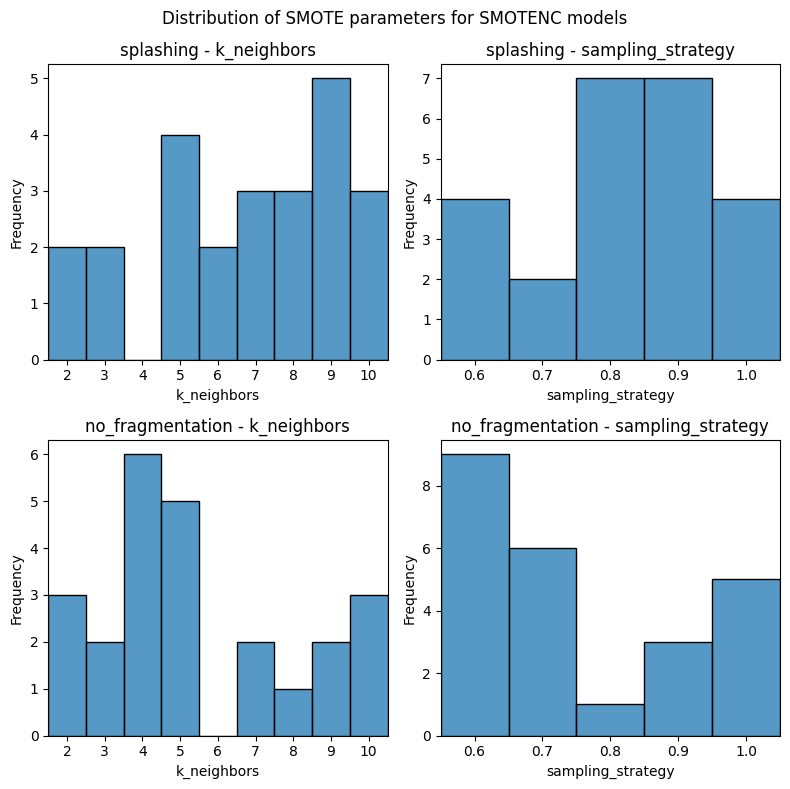

In [17]:
plot_SMOTE_params_distribution(
    plot_df=df[df['SMOTE'] == 'SMOTENC'],
    # top_n=24,
    title='Distribution of SMOTE parameters for SMOTENC models',
    verbose=True,
    save_name='SMOTE_params_distribution_5_1_SMOTENC_models',
)

Size of the full_target_df for splashing: 24 rows
Size of the target_df for splashing: 12 rows
Models composition:


XGBClassifier             3
CatBoostClassifier        3
LGBMClassifier            3
KNeighborsClassifier      2
RandomForestClassifier    1
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    12
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.90,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
158,CatBoostClassifier,splashing,SMOTENC,optuna,mean,7,0.75,0.850000,0.958333,0.839120,0.898584,0.945820,0.903251,0.996309,0.999678,0.995238,0.996567,0.999592,0.995575
144,XGBClassifier,splashing,SMOTENC,grid,mean,10,0.80,0.846814,0.942901,0.831019,0.879545,0.947619,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
166,LGBMClassifier,splashing,SMOTENC,optuna,mean,5,0.83,0.836601,0.948688,0.828704,0.879545,0.952012,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
84,LGBMClassifier,splashing,SMOTENC,grid,median,2,0.80,0.836601,0.939815,0.828704,0.896201,0.941270,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
154,KNeighborsClassifier,splashing,SMOTENC,optuna,mean,9,0.73,0.836601,0.883488,0.828704,0.844575,0.930075,0.870743,0.891299,0.974082,0.898140,0.886453,0.972592,0.892255
76,CatBoostClassifier,splashing,SMOTENC,grid,median,7,0.90,0.823391,0.952932,0.818287,0.860788,0.955108,0.873839,0.996309,0.999777,0.995238,0.996567,0.999592,0.995575


Size of the full_target_df for no_fragmentation: 24 rows
Size of the target_df for no_fragmentation: 12 rows
Models composition:


LGBMClassifier            3
XGBClassifier             3
CatBoostClassifier        3
RandomForestClassifier    3
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    12
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.99995,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
83,RandomForestClassifier,no_fragmentation,SMOTENC,grid,median,5,0.70,0.900794,0.980000,0.913636,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
77,CatBoostClassifier,no_fragmentation,SMOTENC,grid,median,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.00000,1.000000
143,CatBoostClassifier,no_fragmentation,SMOTENC,grid,mean,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.00000,1.000000
145,XGBClassifier,no_fragmentation,SMOTENC,grid,mean,5,1.00,0.885894,0.988182,0.904545,0.875762,0.967033,0.877289,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


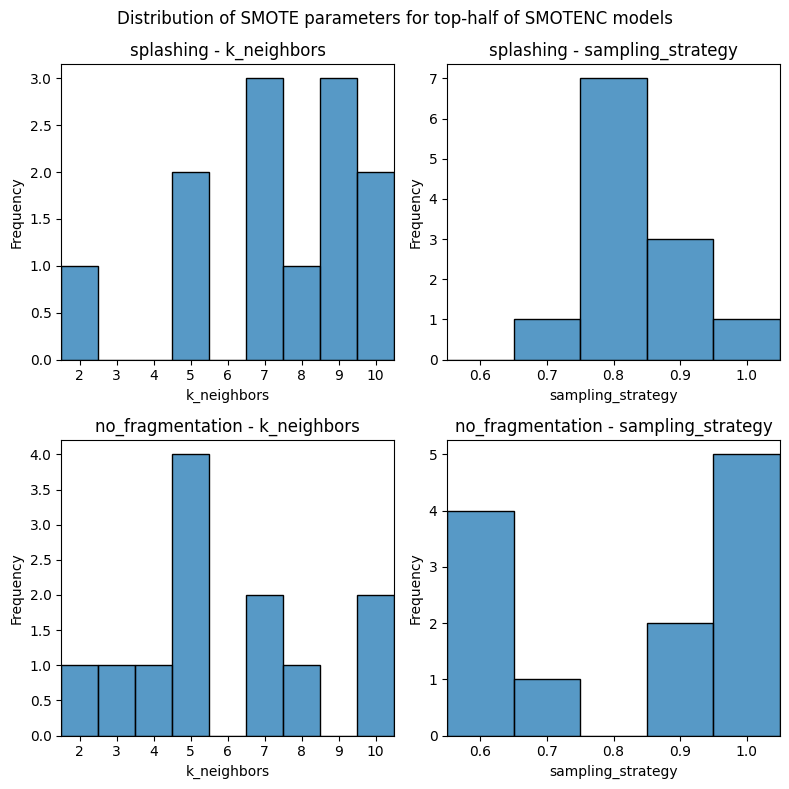

In [18]:
plot_SMOTE_params_distribution(
    plot_df=df[df['SMOTE'] == 'SMOTENC'],
    top_n=12,
    title='Distribution of SMOTE parameters for top-half of SMOTENC models',
    verbose=True,
    save_name='SMOTE_params_distribution_5_2_top_half_SMOTENC_models',
)

Size of the full_target_df for splashing: 15 rows
Size of the target_df for splashing: 15 rows
Models composition:


XGBClassifier             3
CatBoostClassifier        3
LGBMClassifier            3
RandomForestClassifier    3
AdaBoostClassifier        3
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    15
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.90,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
158,CatBoostClassifier,splashing,SMOTENC,optuna,mean,7,0.75,0.850000,0.958333,0.839120,0.898584,0.945820,0.903251,0.996309,0.999678,0.995238,0.996567,0.999592,0.995575
144,XGBClassifier,splashing,SMOTENC,grid,mean,10,0.80,0.846814,0.942901,0.831019,0.879545,0.947619,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
166,LGBMClassifier,splashing,SMOTENC,optuna,mean,5,0.83,0.836601,0.948688,0.828704,0.879545,0.952012,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
84,LGBMClassifier,splashing,SMOTENC,grid,median,2,0.80,0.836601,0.939815,0.828704,0.896201,0.941270,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
76,CatBoostClassifier,splashing,SMOTENC,grid,median,7,0.90,0.823391,0.952932,0.818287,0.860788,0.955108,0.873839,0.996309,0.999777,0.995238,0.996567,0.999592,0.995575
148,RandomForestClassifier,splashing,SMOTENC,grid,mean,9,0.80,0.816176,0.951775,0.802083,0.896201,0.945820,0.891641,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 15 rows
Size of the target_df for no_fragmentation: 15 rows
Models composition:


LGBMClassifier            3
XGBClassifier             3
CatBoostClassifier        3
RandomForestClassifier    3
AdaBoostClassifier        3
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    15
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.999950,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
83,RandomForestClassifier,no_fragmentation,SMOTENC,grid,median,5,0.70,0.900794,0.980000,0.913636,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
77,CatBoostClassifier,no_fragmentation,SMOTENC,grid,median,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.000000,1.000000
143,CatBoostClassifier,no_fragmentation,SMOTENC,grid,mean,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.000000,1.000000
145,XGBClassifier,no_fragmentation,SMOTENC,grid,mean,5,1.00,0.885894,0.988182,0.904545,0.875762,0.967033,0.877289,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


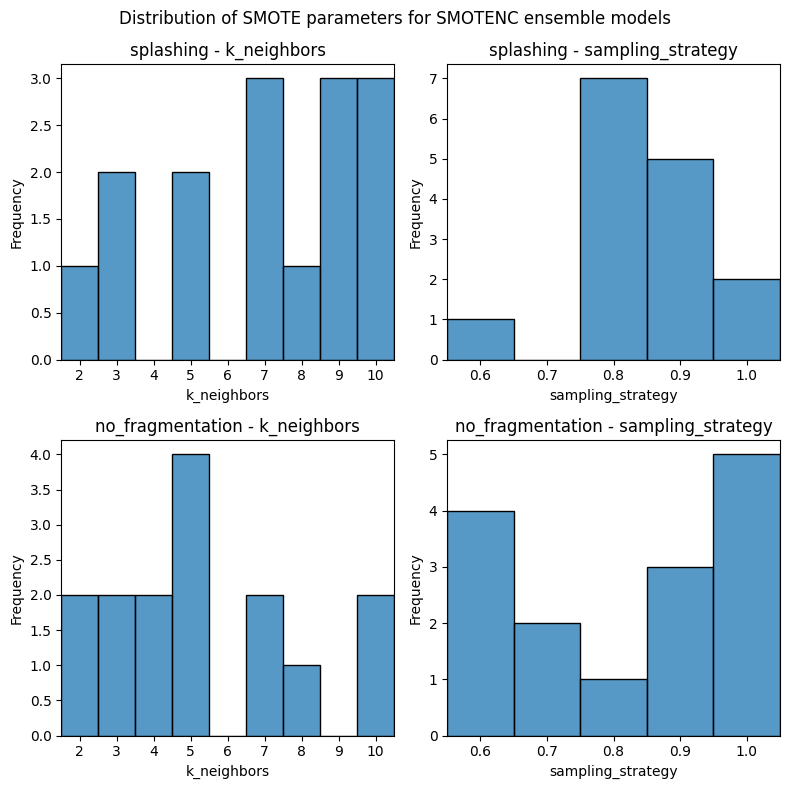

In [19]:
plot_SMOTE_params_distribution(
    plot_df=df[(df['SMOTE'] == 'SMOTENC') & (df['model_class'].isin(ensemble_models))],
    # top_n=24,
    title='Distribution of SMOTE parameters for SMOTENC ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_5_3_SMOTENC_ensemble_models',
)

Size of the full_target_df for splashing: 15 rows
Size of the target_df for splashing: 8 rows
Models composition:


XGBClassifier         3
LGBMClassifier        3
CatBoostClassifier    2
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.90,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
158,CatBoostClassifier,splashing,SMOTENC,optuna,mean,7,0.75,0.850000,0.958333,0.839120,0.898584,0.945820,0.903251,0.996309,0.999678,0.995238,0.996567,0.999592,0.995575
144,XGBClassifier,splashing,SMOTENC,grid,mean,10,0.80,0.846814,0.942901,0.831019,0.879545,0.947619,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
166,LGBMClassifier,splashing,SMOTENC,optuna,mean,5,0.83,0.836601,0.948688,0.828704,0.879545,0.952012,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
84,LGBMClassifier,splashing,SMOTENC,grid,median,2,0.80,0.836601,0.939815,0.828704,0.896201,0.941270,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 15 rows
Size of the target_df for no_fragmentation: 8 rows
Models composition:


LGBMClassifier            3
CatBoostClassifier        2
RandomForestClassifier    2
XGBClassifier             1
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.00,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.60,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.99995,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
83,RandomForestClassifier,no_fragmentation,SMOTENC,grid,median,5,0.70,0.900794,0.980000,0.913636,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
77,CatBoostClassifier,no_fragmentation,SMOTENC,grid,median,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.00000,1.000000


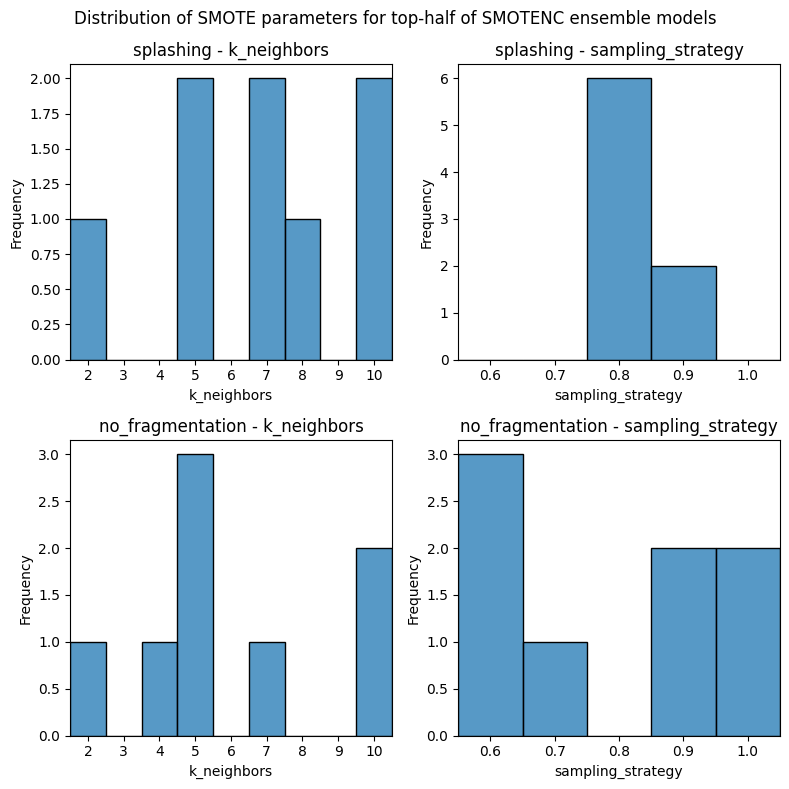

In [20]:
plot_SMOTE_params_distribution(
    plot_df=df[(df['SMOTE'] == 'SMOTENC') & (df['model_class'].isin(ensemble_models))],
    top_n=8,
    title='Distribution of SMOTE parameters for top-half of SMOTENC ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_5_4_top_half_SMOTENC_ensemble_models',
)

### Division by optimization method

Size of the full_target_df for splashing: 16 rows
Size of the target_df for splashing: 16 rows
Models composition:


XGBClassifier             2
CatBoostClassifier        2
LGBMClassifier            2
RandomForestClassifier    2
SVC                       2
KNeighborsClassifier      2
LogisticRegression        2
AdaBoostClassifier        2
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    8
SMOTE      8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
78,XGBClassifier,splashing,SMOTENC,grid,median,5,0.9,0.896019,0.942130,0.886574,0.873810,0.948916,0.873839,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
62,XGBClassifier,splashing,SMOTE,grid,median,7,1.0,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
60,CatBoostClassifier,splashing,SMOTE,grid,median,10,0.6,0.846814,0.959877,0.831019,0.896201,0.950464,0.891641,0.996309,0.999975,0.995238,0.996567,0.999463,0.995575
68,LGBMClassifier,splashing,SMOTE,grid,median,7,0.9,0.836601,0.951775,0.828704,0.898584,0.958730,0.903251,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
84,LGBMClassifier,splashing,SMOTENC,grid,median,2,0.8,0.836601,0.939815,0.828704,0.896201,0.941270,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
66,RandomForestClassifier,splashing,SMOTE,grid,median,4,0.7,0.833300,0.956404,0.820602,0.896201,0.948413,0.891641,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
76,CatBoostClassifier,splashing,SMOTENC,grid,median,7,0.9,0.823391,0.952932,0.818287,0.860788,0.955108,0.873839,0.996309,0.999777,0.995238,0.996567,0.999592,0.995575
74,SVC,splashing,SMOTENC,grid,median,5,0.6,0.810348,0.906636,0.807870,0.863049,0.928793,0.876935,0.877724,0.948884,0.887723,0.872228,0.949845,0.879801
56,KNeighborsClassifier,splashing,SMOTE,grid,median,5,0.7,0.810348,0.874228,0.807870,0.835913,0.918731,0.844427,0.887457,0.973884,0.893378,0.888444,0.972957,0.897070
82,RandomForestClassifier,splashing,SMOTENC,grid,median,9,1.0,0.806892,0.934799,0.799769,0.876935,0.948142,0.876935,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 16 rows
Size of the target_df for no_fragmentation: 16 rows
Models composition:


LGBMClassifier            2
CatBoostClassifier        2
XGBClassifier             2
RandomForestClassifier    2
SVC                       2
AdaBoostClassifier        2
KNeighborsClassifier      2
LogisticRegression        2
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    8
SMOTE      8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
85,LGBMClassifier,no_fragmentation,SMOTENC,grid,median,4,1.0,0.933862,0.990000,0.947727,0.876543,0.979487,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
61,CatBoostClassifier,no_fragmentation,SMOTE,grid,median,5,1.0,0.933862,0.987273,0.947727,0.925457,0.977778,0.915751,0.991446,0.999884,0.995413,0.992040,1.000000,0.995726
79,XGBClassifier,no_fragmentation,SMOTENC,grid,median,2,0.6,0.931818,0.991818,0.931818,0.854396,0.978022,0.854396,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
83,RandomForestClassifier,no_fragmentation,SMOTENC,grid,median,5,0.7,0.900794,0.980000,0.913636,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
67,RandomForestClassifier,no_fragmentation,SMOTE,grid,median,5,0.6,0.897727,0.980455,0.897727,0.898077,0.946154,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
77,CatBoostClassifier,no_fragmentation,SMOTENC,grid,median,7,0.6,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.000000,1.000000
69,LGBMClassifier,no_fragmentation,SMOTE,grid,median,3,0.9,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
63,XGBClassifier,no_fragmentation,SMOTE,grid,median,8,0.9,0.882524,0.981818,0.888636,0.875762,0.976068,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
59,SVC,no_fragmentation,SMOTE,grid,median,9,0.7,0.857143,0.950000,0.886364,0.850704,0.948718,0.877289,0.869951,0.961154,0.894321,0.865626,0.959226,0.902778
65,AdaBoostClassifier,no_fragmentation,SMOTE,grid,median,6,0.6,0.853293,0.949091,0.870455,0.854396,0.925824,0.854396,0.966307,0.995819,0.977616,0.956692,0.996129,0.965259


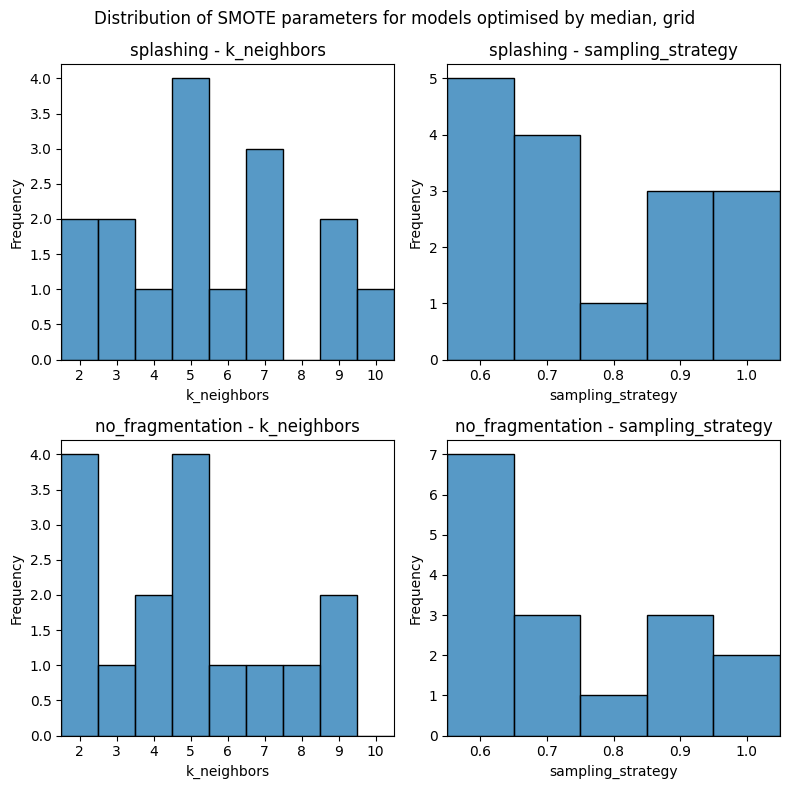

In [21]:
plot_SMOTE_params_distribution(
    plot_df=df[df['SMOTE_opt_type'] == 'median'],
    # top_n=24,
    title='Distribution of SMOTE parameters for models optimised by median, grid',
    verbose=True,
    save_name='SMOTE_params_distribution_6_1_median_grid',
)

Size of the full_target_df for splashing: 16 rows
Size of the target_df for splashing: 16 rows
Models composition:


CatBoostClassifier        2
LGBMClassifier            2
XGBClassifier             2
KNeighborsClassifier      2
RandomForestClassifier    2
SVC                       2
LogisticRegression        2
AdaBoostClassifier        2
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    8
SMOTE      8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.9,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.8,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.9,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.0,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.0,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
144,XGBClassifier,splashing,SMOTENC,grid,mean,10,0.8,0.846814,0.942901,0.831019,0.879545,0.947619,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
106,KNeighborsClassifier,splashing,SMOTE,grid,mean,10,0.8,0.842105,0.874228,0.844907,0.842262,0.923375,0.859133,0.881535,0.976612,0.892485,0.885678,0.974031,0.893505
116,RandomForestClassifier,splashing,SMOTE,grid,mean,3,0.9,0.820000,0.953318,0.810185,0.873810,0.946032,0.873810,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
148,RandomForestClassifier,splashing,SMOTENC,grid,mean,9,0.8,0.816176,0.951775,0.802083,0.896201,0.945820,0.891641,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
108,SVC,splashing,SMOTE,grid,mean,10,1.0,0.813397,0.904321,0.815972,0.826230,0.922601,0.856037,0.875636,0.948884,0.891592,0.867271,0.946838,0.880939


Size of the full_target_df for no_fragmentation: 16 rows
Size of the target_df for no_fragmentation: 16 rows
Models composition:


LGBMClassifier            2
CatBoostClassifier        2
XGBClassifier             2
RandomForestClassifier    2
AdaBoostClassifier        2
KNeighborsClassifier      2
SVC                       2
LogisticRegression        2
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    8
SMOTE      8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.9,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
111,CatBoostClassifier,no_fragmentation,SMOTE,grid,mean,7,0.6,0.897727,0.985455,0.897727,0.898077,0.969231,0.880037,0.991446,0.999826,0.995413,0.995975,1.000000,0.994118
143,CatBoostClassifier,no_fragmentation,SMOTENC,grid,mean,7,0.6,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.000000,1.000000
145,XGBClassifier,no_fragmentation,SMOTENC,grid,mean,5,1.0,0.885894,0.988182,0.904545,0.875762,0.967033,0.877289,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
119,LGBMClassifier,no_fragmentation,SMOTE,grid,mean,3,0.9,0.885894,0.980909,0.904545,0.875762,0.958974,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
117,RandomForestClassifier,no_fragmentation,SMOTE,grid,mean,8,0.9,0.885894,0.977727,0.904545,0.875762,0.932479,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
113,XGBClassifier,no_fragmentation,SMOTE,grid,mean,8,0.9,0.882524,0.981818,0.888636,0.875762,0.976068,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
149,RandomForestClassifier,no_fragmentation,SMOTENC,grid,mean,8,1.0,0.867725,0.977727,0.879545,0.898077,0.943590,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
115,AdaBoostClassifier,no_fragmentation,SMOTE,grid,mean,6,0.6,0.853293,0.949091,0.870455,0.854396,0.925824,0.854396,0.966307,0.995819,0.977616,0.956692,0.996129,0.965259
139,KNeighborsClassifier,no_fragmentation,SMOTENC,grid,mean,5,0.7,0.834656,0.947727,0.845455,0.854396,0.931319,0.854396,0.893613,0.976164,0.916154,0.875179,0.977275,0.899522


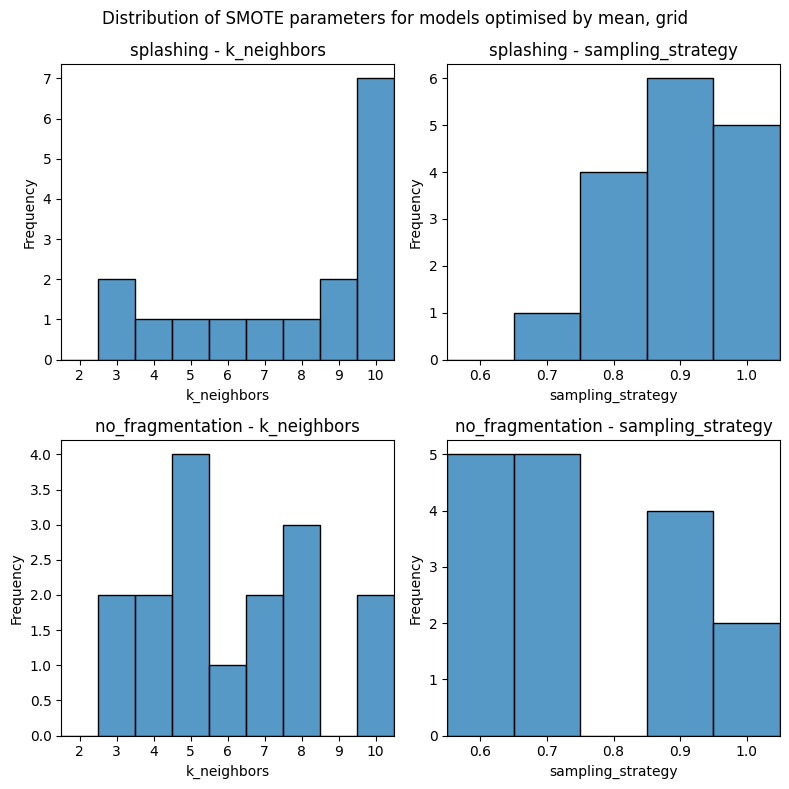

In [22]:
plot_SMOTE_params_distribution(
    plot_df=df[(df['SMOTE_opt_type'] == 'mean') & (df['SMOTE_opt'] == 'grid')],
    # top_n=24,
    title='Distribution of SMOTE parameters for models optimised by mean, grid',
    verbose=True,
    save_name='SMOTE_params_distribution_6_2_mean_grid',
)

Size of the full_target_df for splashing: 16 rows
Size of the target_df for splashing: 16 rows
Models composition:


XGBClassifier             2
CatBoostClassifier        2
LGBMClassifier            2
KNeighborsClassifier      2
RandomForestClassifier    2
SVC                       2
LogisticRegression        2
AdaBoostClassifier        2
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    8
SMOTE      8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
158,CatBoostClassifier,splashing,SMOTENC,optuna,mean,7,0.75,0.850000,0.958333,0.839120,0.898584,0.945820,0.903251,0.996309,0.999678,0.995238,0.996567,0.999592,0.995575
166,LGBMClassifier,splashing,SMOTENC,optuna,mean,5,0.83,0.836601,0.948688,0.828704,0.879545,0.952012,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
128,XGBClassifier,splashing,SMOTE,optuna,mean,7,0.94,0.836601,0.944830,0.828704,0.876935,0.953560,0.876935,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
154,KNeighborsClassifier,splashing,SMOTENC,optuna,mean,9,0.73,0.836601,0.883488,0.828704,0.844575,0.930075,0.870743,0.891299,0.974082,0.898140,0.886453,0.972592,0.892255
122,KNeighborsClassifier,splashing,SMOTE,optuna,mean,9,0.95,0.829027,0.891204,0.834491,0.846377,0.929323,0.876935,0.896614,0.979167,0.911533,0.887862,0.976093,0.905413
132,RandomForestClassifier,splashing,SMOTE,optuna,mean,3,0.90,0.820000,0.953318,0.810185,0.873810,0.946032,0.873810,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
156,SVC,splashing,SMOTENC,optuna,mean,8,0.92,0.810348,0.893519,0.807870,0.844575,0.934985,0.870743,0.878583,0.951215,0.892039,0.866850,0.946366,0.877373


Size of the full_target_df for no_fragmentation: 16 rows
Size of the target_df for no_fragmentation: 16 rows
Models composition:


XGBClassifier             2
CatBoostClassifier        2
RandomForestClassifier    2
LGBMClassifier            2
SVC                       2
KNeighborsClassifier      2
AdaBoostClassifier        2
LogisticRegression        2
Name: model_class, dtype: int64

SMOTE types:


SMOTE      8
SMOTENC    8
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.999950,0.995726
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.999950,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
133,RandomForestClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.75,0.903516,0.980455,0.929545,0.875762,0.954701,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
161,XGBClassifier,no_fragmentation,SMOTENC,optuna,mean,3,0.99,0.882524,0.977273,0.888636,0.875762,0.968864,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
125,SVC,no_fragmentation,SMOTE,optuna,mean,3,0.67,0.857143,0.950909,0.886364,0.881326,0.948718,0.890110,0.878079,0.963012,0.902944,0.857399,0.954449,0.885093
157,SVC,no_fragmentation,SMOTENC,optuna,mean,4,0.72,0.843227,0.952727,0.877273,0.850704,0.961538,0.890110,0.869951,0.962838,0.894321,0.865626,0.960282,0.899522


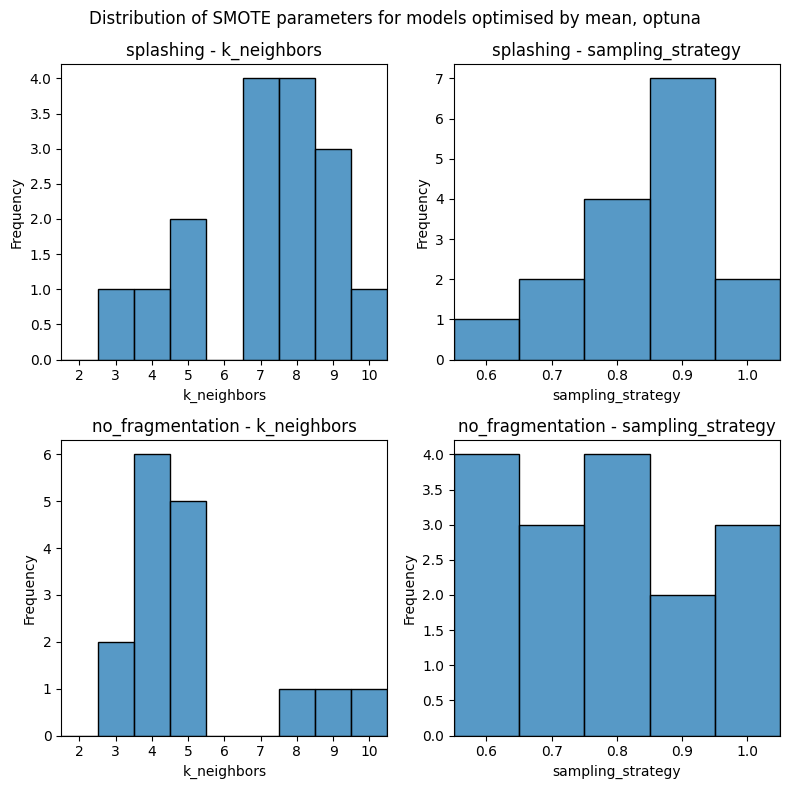

In [23]:
plot_SMOTE_params_distribution(
    plot_df=df[(df['SMOTE_opt_type'] == 'mean') & (df['SMOTE_opt'] == 'optuna')],
    # top_n=24,
    title='Distribution of SMOTE parameters for models optimised by mean, optuna',
    verbose=True,
    save_name='SMOTE_params_distribution_6_3_mean_optuna',
)

Size of the full_target_df for splashing: 20 rows
Size of the target_df for splashing: 20 rows
Models composition:


CatBoostClassifier        4
LGBMClassifier            4
XGBClassifier             4
RandomForestClassifier    4
AdaBoostClassifier        4
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    10
SMOTE      10
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
158,CatBoostClassifier,splashing,SMOTENC,optuna,mean,7,0.75,0.850000,0.958333,0.839120,0.898584,0.945820,0.903251,0.996309,0.999678,0.995238,0.996567,0.999592,0.995575
144,XGBClassifier,splashing,SMOTENC,grid,mean,10,0.80,0.846814,0.942901,0.831019,0.879545,0.947619,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 20 rows
Size of the target_df for no_fragmentation: 20 rows
Models composition:


LGBMClassifier            4
XGBClassifier             4
CatBoostClassifier        4
RandomForestClassifier    4
AdaBoostClassifier        4
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    10
SMOTE      10
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.999950,0.995726
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.999950,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
133,RandomForestClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.75,0.903516,0.980455,0.929545,0.875762,0.954701,0.867216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
111,CatBoostClassifier,no_fragmentation,SMOTE,grid,mean,7,0.60,0.897727,0.985455,0.897727,0.898077,0.969231,0.880037,0.991446,0.999826,0.995413,0.995975,1.000000,0.994118
143,CatBoostClassifier,no_fragmentation,SMOTENC,grid,mean,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.000000,1.000000


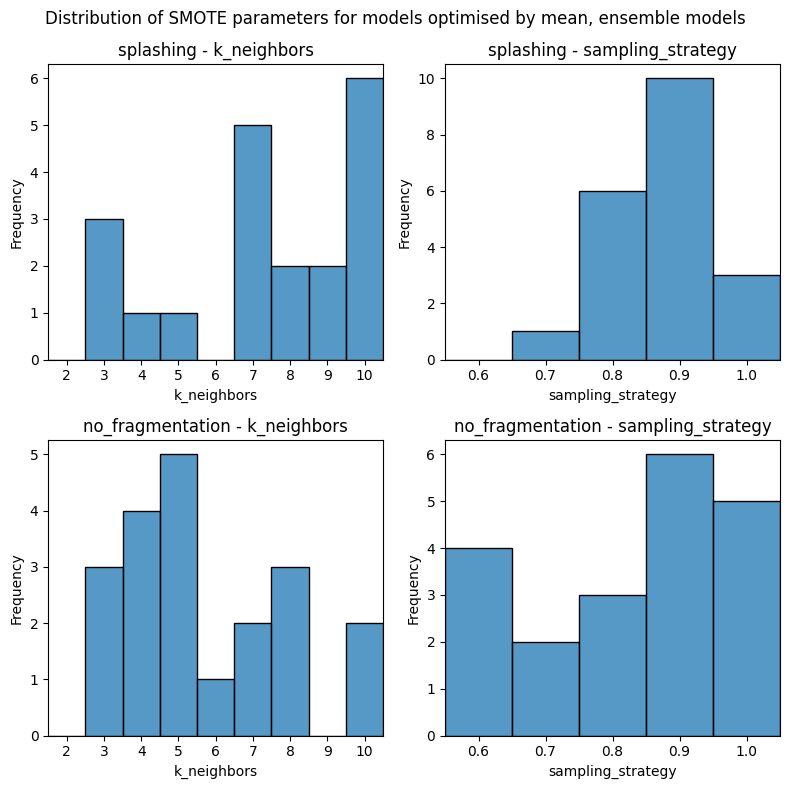

In [25]:
plot_SMOTE_params_distribution(
    plot_df=df[(df['SMOTE_opt_type'] == 'mean') & (df['model_class'].isin(ensemble_models))],
    # top_n=24,
    title='Distribution of SMOTE parameters for models optimised by mean, ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_6_4_mean_ensemble_models',
)

Size of the full_target_df for splashing: 20 rows
Size of the target_df for splashing: 10 rows
Models composition:


CatBoostClassifier    4
LGBMClassifier        3
XGBClassifier         3
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    5
SMOTE      5
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
142,CatBoostClassifier,splashing,SMOTENC,grid,mean,10,0.90,0.882261,0.956019,0.876157,0.876935,0.956656,0.876935,0.996309,0.999975,0.995238,0.996567,0.999678,0.995575
150,LGBMClassifier,splashing,SMOTENC,grid,mean,8,0.80,0.882261,0.954861,0.876157,0.881696,0.952012,0.900155,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
110,CatBoostClassifier,splashing,SMOTE,grid,mean,10,0.90,0.882261,0.953704,0.876157,0.876935,0.952012,0.887302,0.996309,0.999975,0.995238,0.996567,0.999635,0.995575
160,XGBClassifier,splashing,SMOTENC,optuna,mean,7,0.83,0.880000,0.939429,0.868056,0.831746,0.950464,0.844444,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
126,CatBoostClassifier,splashing,SMOTE,optuna,mean,4,0.69,0.863609,0.956790,0.849537,0.881696,0.952012,0.900155,0.996309,0.999678,0.995238,0.996567,0.999678,0.995575
118,LGBMClassifier,splashing,SMOTE,grid,mean,10,1.00,0.863609,0.950617,0.849537,0.879545,0.958204,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
134,LGBMClassifier,splashing,SMOTE,optuna,mean,7,0.88,0.852826,0.949846,0.847222,0.858018,0.953968,0.862229,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
112,XGBClassifier,splashing,SMOTE,grid,mean,7,1.00,0.852826,0.947145,0.847222,0.850704,0.946032,0.856037,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575
158,CatBoostClassifier,splashing,SMOTENC,optuna,mean,7,0.75,0.850000,0.958333,0.839120,0.898584,0.945820,0.903251,0.996309,0.999678,0.995238,0.996567,0.999592,0.995575
144,XGBClassifier,splashing,SMOTENC,grid,mean,10,0.80,0.846814,0.942901,0.831019,0.879545,0.947619,0.888545,0.996309,0.999975,0.995238,0.996567,0.999979,0.995575


Size of the full_target_df for no_fragmentation: 20 rows
Size of the target_df for no_fragmentation: 10 rows
Models composition:


CatBoostClassifier        4
LGBMClassifier            3
RandomForestClassifier    2
XGBClassifier             1
Name: model_class, dtype: int64

SMOTE types:


SMOTENC    5
SMOTE      5
Name: SMOTE, dtype: int64

,model_class,target,SMOTE,SMOTE_opt,SMOTE_opt_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,holdout_test_roc_auc,holdout_test_accuracy_balanced,cv_test_f1_macro_median,cv_test_roc_auc_median,cv_test_accuracy_balanced_median,holdout_train_f1_macro,holdout_train_roc_auc,holdout_train_accuracy_balanced,cv_train_f1_macro_median,cv_train_roc_auc_median,cv_train_accuracy_balanced_median
151,LGBMClassifier,no_fragmentation,SMOTENC,grid,mean,10,0.90,0.933862,0.989091,0.947727,0.876543,0.964103,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
129,XGBClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.95,0.918496,0.990909,0.938636,0.875762,0.962393,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
127,CatBoostClassifier,no_fragmentation,SMOTE,optuna,mean,4,0.74,0.918496,0.984545,0.938636,0.902930,0.972650,0.887363,0.991446,0.999884,0.995413,0.992040,0.99995,0.995726
159,CatBoostClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.61,0.916089,0.987273,0.922727,0.902930,0.974359,0.892857,0.995706,0.999942,0.997706,0.996005,0.99995,0.997863
165,RandomForestClassifier,no_fragmentation,SMOTENC,optuna,mean,5,0.96,0.916089,0.983636,0.922727,0.875762,0.948718,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
167,LGBMClassifier,no_fragmentation,SMOTENC,optuna,mean,10,0.86,0.916089,0.980000,0.922727,0.898077,0.967521,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
135,LGBMClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.88,0.913375,0.989091,0.906818,0.898077,0.970940,0.880037,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
133,RandomForestClassifier,no_fragmentation,SMOTE,optuna,mean,5,0.75,0.903516,0.980455,0.929545,0.875762,0.954701,0.867216,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
111,CatBoostClassifier,no_fragmentation,SMOTE,grid,mean,7,0.60,0.897727,0.985455,0.897727,0.898077,0.969231,0.880037,0.991446,0.999826,0.995413,0.995975,1.00000,0.994118
143,CatBoostClassifier,no_fragmentation,SMOTENC,grid,mean,7,0.60,0.897727,0.979091,0.897727,0.898077,0.970940,0.880037,0.995706,0.999884,0.997706,1.000000,1.00000,1.000000


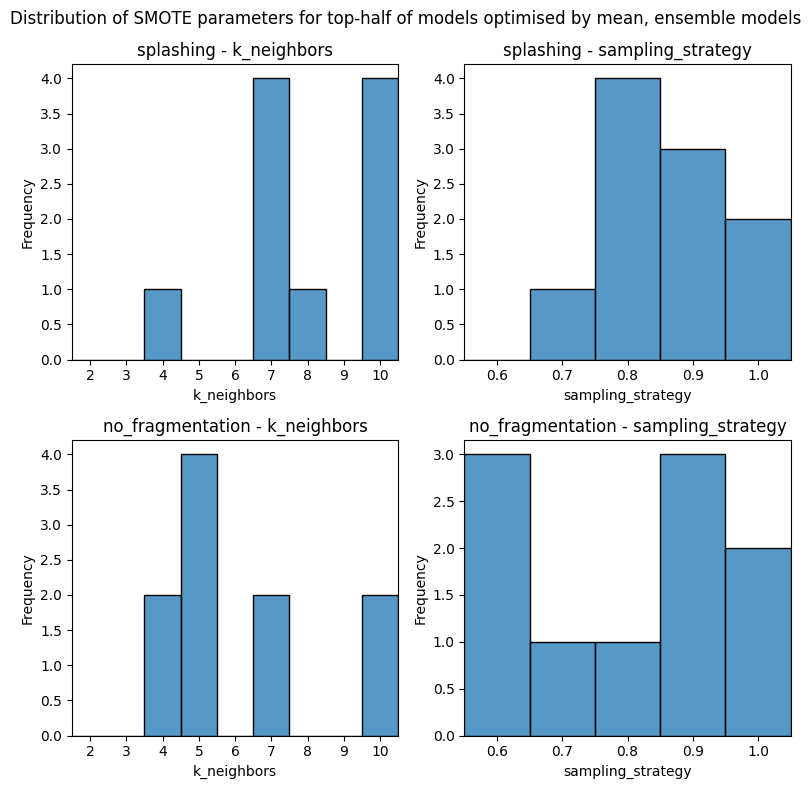

In [26]:
plot_SMOTE_params_distribution(
    plot_df=df[(df['SMOTE_opt_type'] == 'mean') & (df['model_class'].isin(ensemble_models))],
    top_n=10,
    title='Distribution of SMOTE parameters for top-half of models optimised by mean, ensemble models',
    verbose=True,
    save_name='SMOTE_params_distribution_6_5_top_half_mean_ensemble_models',
)

# Размышления

**По графикам всех моделей (1_1, 6_1-6_3):**

При осреднении по средней метрике, что grid, что optuna, значение k_neighbors = 2 исчезает. При этом, оно принимет одно из максимальных значений для median - no_fragmentation. Но всё таки, предлагаю его исключить из рассмотрения,

По "no_fragmentation", чаще всего выбираются `k_neighbors = 5`. k_neighbors = 4 побеждает только один раз, при использовании optuna вместо grid search

По "no_fragmentation", sampling_strategy, значение 0.6 выигрывает везде. На уровне с ним, по числу моделей, значение 0.7 в mean, grid; и 0.8 в mean, optuna

По "splaghing" всё сложнее и неоднозначнее. Для k_neighbors претенденты: 5, 7, 9, 10. 
При старом методе оптимизации (median) выигрывают 5 и 7. Однако, при mean предпочтение отдавалось 10 для gridsearch, и 7-8 для optuna

Для sampling_strategy: 0.9 выбирается чаще всего (только для median, grid 0.6 было в приоритете)

Таким образом, можно было бы предварительно выделить следующие параметры:
- `Splashing: k_neighbors = 7, sampling_strategy=0.9`
- `No_fragmentation: k_neighbors=5, sampling_strategy=0.6`

для топ-50% лучших моделей на holdout (1_2): splashing выбор подтверждается, для no_fragmentation, подтверждается только k_neighbors, а вот sampling_strategy вдруг 0.9 начинает лидировать

**Рассмотрим теперь статистику по моделям из ансамблей (3_1, 3_2):**

- для Splashing всё подтверждается
- для no_fragmentation 0.9 ещё лидирует, если смотреть на все модели. Однако, для топовых ансамблей, подтверждается следующий выбор No_fragmentation: k_neighbors=5, sampling_strategy=0.6



Сфокусируемся на топовых ансамблевых моделях, и посмотрим разбивку по SMOTE[NC] (4_4, 5_4)

в целом, разбивка плюс минус подтверждается, с той разницей, что есть ещё значения, которые столько же выбираются, сколько предварительно отобранные.

Как вариант, для Splashing взять `sampling_strategy = 0.8` по SMOTENC

## С учётом разбивки на SMOTE/SMOTENC:

SMOTE:
- `Splashing: k_neighbors = 7, sampling_strategy=0.9`
- `No_fragmentation: k_neighbors=5, sampling_strategy=0.6`

SMOTENC:
- `Splashing: k_neighbors = 7, sampling_strategy=0.8`
- `No_fragmentation: k_neighbors=5, sampling_strategy=0.6`